# Test Git V4

In [20]:
print("test")

test


In [21]:
print("test")

test


# PlankEye — DATA_KAGGLE_V2 — 2×T4 — ImageNet au départ + reprise automatique

Ce notebook entraîne **PlankEye, le modèle de détection des planches et de leurs 4 coins**.

Le nouveau dataset est `data_kaggle_v2` (réel + images créées par le GAN), mais le modèle entraîné ici **n'est pas un GAN**.

## Fonctionnement

### Premier lancement
S'il n'existe aucun checkpoint compatible :

- architecture PlankEye v3 ;
- backbone **MobileNetV3-Large** ;
- poids **ImageNet préentraînés** ;
- aucun ancien checkpoint PlankEye ;
- aucun warm-start ;
- départ à l'epoch 1.

### Relance
Si `last_plankeye_v4_1class_512_data_kaggle.pt` existe et appartient à l'expérience `plankeye_data_kaggle_imagenet_v1` :

- les poids complets PlankEye sont restaurés ;
- l'optimiseur est restauré ;
- l'EMA et le GradScaler sont restaurés ;
- les historiques sont restaurés ;
- l'entraînement reprend à `dernier_epoch + 1`.

### Sauvegarde
- `last` : à chaque epoch en local ;
- `best` : à chaque amélioration ;
- `best + last` : sauvegarde persistante Kaggle tous les 5 epochs ;
- nouvelle session : recherche automatique du checkpoint dans `/kaggle/input`, puis tentative de téléchargement depuis `max778/checkpoints_plankeye_kaggle_v2`.

## Configuration
- 2× Tesla T4
- DDP FileStore
- 512×512
- batch 8/GPU
- batch global 16
- 180 epochs maximum
- 1 classe `planche`


## 1 — Vérifier les 2 GPU, Internet et la CLI Kaggle


In [22]:
!nvidia-smi

import shutil
import socket
import subprocess
import torch

print("\n=== GPU ===")
print("PyTorch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("CUDA absent. Active GPU T4 x2 dans Kaggle.")

n_gpus = torch.cuda.device_count()
print("Nombre de GPU :", n_gpus)

for i in range(n_gpus):
    props = torch.cuda.get_device_properties(i)
    print(
        f"GPU {i}: {torch.cuda.get_device_name(i)} | "
        f"VRAM={props.total_memory / 1024**3:.2f} Go"
    )

if n_gpus < 2:
    raise RuntimeError(
        "Ce notebook exige 2 GPU. Sélectionne GPU T4 x2 avant de continuer."
    )

print("\nOK : 2 GPU détectés.")

print("\n=== INTERNET ===")
try:
    ip = socket.gethostbyname("api.kaggle.com")
    print("api.kaggle.com ->", ip)
except Exception as exc:
    raise RuntimeError(
        "Internet/DNS Kaggle indisponible. Active Internet dans Settings."
    ) from exc

print("\n=== CLI KAGGLE ===")
kaggle_exe = shutil.which("kaggle")
if kaggle_exe is None:
    raise RuntimeError("Commande 'kaggle' introuvable.")

print("CLI :", kaggle_exe)
result = subprocess.run(
    [kaggle_exe, "datasets", "list", "-m"],
    text=True,
    capture_output=True,
)

if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    raise RuntimeError("La CLI Kaggle n'est pas authentifiée correctement.")

print("Authentification Kaggle : OK")
print("\n".join(result.stdout.splitlines()[:6]))

Mon Sep  7 08:30:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P0             30W /   70W |    3095MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2 — Cloner le dépôt GitHub privé

Cette cellule récupère automatiquement la dernière version de :

```text
maaxxe/Train_Kaggle_plank_Detector
└── model/
    └── model.py
```

Le token reste dans **Kaggle Secrets** et n'est jamais affiché.


In [23]:
from pathlib import Path
from kaggle_secrets import UserSecretsClient
import subprocess
import shutil
import os

# ============================================================
# CONFIG
# ============================================================

GITHUB_USERNAME = "maaxxe"
GITHUB_REPO = "Train_Kaggle_plank_Detector"

GITHUB_REPO_DIR = Path(
    "/kaggle/working/Train_Kaggle_plank_Detector"
)

print("=" * 72)
print("CLONE GITHUB PRIVÉ")
print("=" * 72)

# ============================================================
# TOKEN GITHUB
# ============================================================

token = UserSecretsClient().get_secret("GITHUB_TOKEN")

if not token:
    raise RuntimeError(
        "Secret GITHUB_TOKEN introuvable. "
        "Ajoute-le dans Kaggle > Add-ons/Secrets et active-le pour ce notebook."
    )

# ============================================================
# GIT ASKPASS
# ============================================================

askpass = Path("/tmp/github_askpass.sh")

askpass.write_text(
    """#!/bin/sh
case "$1" in
    *Username*) echo "$GITHUB_USERNAME" ;;
    *Password*) echo "$GITHUB_TOKEN" ;;
esac
""",
    encoding="utf-8",
)

askpass.chmod(0o700)

env = os.environ.copy()
env["GITHUB_USERNAME"] = GITHUB_USERNAME
env["GITHUB_TOKEN"] = token
env["GIT_ASKPASS"] = str(askpass)
env["GIT_TERMINAL_PROMPT"] = "0"

repo_url = (
    f"https://github.com/"
    f"{GITHUB_USERNAME}/{GITHUB_REPO}.git"
)

# ============================================================
# SUPPRESSION ANCIEN CLONE
# ============================================================

if GITHUB_REPO_DIR.exists():
    print("Suppression de l'ancien clone...")
    shutil.rmtree(GITHUB_REPO_DIR)

print("Clone       :", repo_url)
print("Destination :", GITHUB_REPO_DIR)

# ============================================================
# CLONE
# ============================================================

try:
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            repo_url,
            str(GITHUB_REPO_DIR),
        ],
        env=env,
        check=True,
    )

finally:
    if askpass.exists():
        askpass.unlink()

    env.pop("GITHUB_TOKEN", None)
    del token

# ============================================================
# AFFICHAGE ARBORESCENCE
# ============================================================

def print_tree(path: Path, prefix="", max_depth=5, depth=0):

    if depth >= max_depth:
        return

    try:
        entries = sorted(
            path.iterdir(),
            key=lambda p: (p.is_file(), p.name.lower())
        )
    except PermissionError:
        return

    for i, entry in enumerate(entries):

        # On évite d'afficher tout le dossier .git
        if entry.name == ".git":
            continue

        is_last = i == len(entries) - 1

        connector = "└── " if is_last else "├── "

        print(prefix + connector + entry.name)

        if entry.is_dir():

            extension = "    " if is_last else "│   "

            print_tree(
                entry,
                prefix + extension,
                max_depth=max_depth,
                depth=depth + 1,
            )


print()
print("=" * 72)
print("ARBORESCENCE DU REPO")
print("=" * 72)

print(GITHUB_REPO_DIR.name)
print_tree(GITHUB_REPO_DIR)

# ============================================================
# RECHERCHE AUTOMATIQUE DES model.py
# ============================================================

print()
print("=" * 72)
print("FICHIERS model.py TROUVÉS")
print("=" * 72)

model_files = list(
    GITHUB_REPO_DIR.rglob("model.py")
)

if not model_files:
    print("Aucun model.py trouvé.")
else:
    for model in model_files:
        print(model)

print()
print("Repo OK :", GITHUB_REPO_DIR.exists())
print("\nGitHub privé prêt.")

CLONE GITHUB PRIVÉ
Suppression de l'ancien clone...
Clone       : https://github.com/maaxxe/Train_Kaggle_plank_Detector.git
Destination : /kaggle/working/Train_Kaggle_plank_Detector


Cloning into '/kaggle/working/Train_Kaggle_plank_Detector'...



ARBORESCENCE DU REPO
Train_Kaggle_plank_Detector
├── GAN_PlankEYE
│   ├── config.py
│   ├── dataset.py
│   ├── GAN_PlankEye_v2_Kaggle_512.ipynb
│   ├── generate.py
│   ├── models.py
│   ├── prepare_dataset.py
│   ├── README.md
│   ├── train.py
│   └── utils.py
├── GeoNet
│   ├── model
│   │   └── multiforme_model.py
│   └── train
│       └── Train_GeoNet_Kaggle_2xT4.ipynb
├── GeoNet_paddle
│   ├── model
│   │   ├── __init__.py
│   │   └── multiforme_model.py
│   ├── model_poids
│   │   └── .gitkeep
│   ├── tools
│   │   └── export_torch_checkpoint_npz.py
│   ├── train
│   │   ├── train_geonet_baidu.py
│   │   └── Train_GeoNet_Baidu_V100.ipynb
│   └── README.md
├── Plankeye
│   ├── dataset
│   │   ├── model_improved.py
│   │   └── PlankEye_Colab.ipynb
│   ├── model
│   │   ├── model.py
│   │   └── model_v3_.py
│   ├── model_poids
│   │   ├── best_plankeye_v4_1class_512.pt
│   │   └── last_plankeye_v4_1class_512.pt
│   ├── train
│   │   ├── PlankEye_Training_2xT4_2DATA_GAN_PRETRAINED_RE

In [24]:
from pathlib import Path

for p in Path("/kaggle/working").iterdir():
    print(p)

/kaggle/working/checkpoint_data_kaggle_download
/kaggle/working/Train_Kaggle_plank_Detector
/kaggle/working/.virtual_documents
/kaggle/working/PlankEyev2_multipieces


In [25]:
from pathlib import Path

ROOT = Path("/kaggle/working/Train_Kaggle_plank_Detector")

print("Dossiers images trouvés :")
for p in ROOT.rglob("images"):
    if p.is_dir():
        print(" -", p)

print("\nDossiers labels trouvés :")
for p in ROOT.rglob("labels"):
    if p.is_dir():
        print(" -", p)

Dossiers images trouvés :

Dossiers labels trouvés :


In [26]:
from pathlib import Path

INPUT = Path("/kaggle/input/datasets")

print("=== DOSSIERS images ===")
for p in INPUT.rglob("images"):
    if p.is_dir():
        print(p)

print("\n=== DOSSIERS labels ===")
for p in INPUT.rglob("labels"):
    if p.is_dir():
        print(p)

=== DOSSIERS images ===
/kaggle/input/datasets/max778/plankeye/dataset_fusionne/dataset_fusionne/images
/kaggle/input/datasets/max778/plankeye/data_kaggle/data_kaggle/images
/kaggle/input/datasets/max778/plankeye/data_6p/data322_melange/images
/kaggle/input/datasets/max778/plankeye/data_gan/data_gan/images
/kaggle/input/datasets/max778/plankeye/data_kaggle_2/data_kaggle_2/images

=== DOSSIERS labels ===
/kaggle/input/datasets/max778/plankeye/dataset_fusionne/dataset_fusionne/labels
/kaggle/input/datasets/max778/plankeye/data_kaggle/data_kaggle/labels
/kaggle/input/datasets/max778/plankeye/data_6p/data322_melange/labels
/kaggle/input/datasets/max778/plankeye/data_gan/data_gan/labels
/kaggle/input/datasets/max778/plankeye/data_kaggle_2/data_kaggle_2/labels


In [ ]:
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

DATA_DIR = Path("/kaggle/working/PlankEyev2_multipieces/data_kaggle_v2")
IMAGES_DIR = DATA_DIR / "images"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Récupération de la liste des images valides à parcourir
image_files = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS])

corrupted_images = []

# Utilisation de tqdm pour afficher la barre de progression
for img_path in tqdm(image_files, desc="Vérification des images", unit="img"):
    try:
        with Image.open(img_path) as im:
            im.verify()  # Vérifie l'intégrité du fichier image
    except Exception as e:
        corrupted_images.append((img_path.name, str(e)))

print(f"\nNombre de mauvaises paires / images corrompues : {len(corrupted_images)}")
if corrupted_images:
    print("\nListe des images problématiques :")
    for name, err in corrupted_images:
        print(f" - {name} : {err}")
else:
    print("✅ Aucune image corrompue détectée !")

## 3 — Préparer le projet et le nouveau dataset `data_kaggle_v2`

Cette cellule :

- copie `Plankeye/model/model.py` depuis ton dépôt GitHub privé ;
- cherche automatiquement le nouveau dataset `data_kaggle_v2` dans `/kaggle/input` ;
- accepte un dataset dont le dossier racine contient directement `images/` et `labels/` ;
- vérifie les associations image/label ;
- **n'importe aucun ancien checkpoint** ;
- prépare un nouvel entraînement indépendant.


In [30]:
from pathlib import Path
import os
import sys
import shutil
import re
import subprocess
import torch

INPUT_ROOT = Path("/kaggle/input")
PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")

GITHUB_REPO_DIR = Path(
    "/kaggle/working/Train_Kaggle_plank_Detector"
)
GITHUB_MODEL = (
    GITHUB_REPO_DIR
    / "Plankeye"
    / "model"
    / "model.py"
)
LOCAL_MODEL = PROJECT / "model_improved.py"

DATA_DIR = PROJECT / "data_kaggle_v2"

PROJECT.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("PRÉPARATION PLANK EYE — DATA_KAGGLE_2 — FROM SCRATCH")
print("=" * 80)


# ============================================================
# 1. MODÈLE DEPUIS GITHUB
# ============================================================

print("\n=== MODÈLE ===")

if not GITHUB_REPO_DIR.exists():
    raise FileNotFoundError(
        "Repo GitHub privé introuvable :\n"
        f"{GITHUB_REPO_DIR}\n\n"
        "Exécute d'abord la cellule de clone GitHub."
    )

if not GITHUB_MODEL.exists():
    raise FileNotFoundError(
        "model/model.py introuvable :\n"
        f"{GITHUB_MODEL}"
    )

shutil.copy2(GITHUB_MODEL, LOCAL_MODEL)

print("Source :", GITHUB_MODEL)
print("Copié  :", LOCAL_MODEL)
print("OK     :", LOCAL_MODEL.exists())


# ============================================================
# 2. TROUVER DATA_KAGGLE_2
# ============================================================

print("\n=== DATASET DATA_KAGGLE_2 ===")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

dataset_candidates = []

for images_dir in INPUT_ROOT.rglob("images"):
    if not images_dir.is_dir():
        continue

    candidate = images_dir.parent
    labels_dir = candidate / "labels"

    if not labels_dir.is_dir():
        continue

    path_lower = "/".join(candidate.parts).lower()

    # Priorité aux chemins dont le nom rappelle data_kaggle_2
    score = 0
    if candidate.name.lower() == "data_kaggle_2":
        score += 100
    if "data_kaggle_2" in path_lower:
        score += 80
    if "data_kaggle" in path_lower:
        score += 20

    dataset_candidates.append((score, candidate))

if not dataset_candidates:
    raise FileNotFoundError(
        "Aucun dataset avec images/ + labels/ trouvé dans /kaggle/input."
    )

dataset_candidates.sort(
    key=lambda x: (-x[0], str(x[1]))
)

print("Candidats compatibles :")
for score, p in dataset_candidates:
    print(f"  score={score:3d} | {p}")

best_score, src = dataset_candidates[0]

if best_score <= 0 and len(dataset_candidates) > 1:
    raise RuntimeError(
        "Plusieurs datasets compatibles trouvés mais aucun ne ressemble "
        "clairement à data_kaggle_2. Vérifie les Inputs Kaggle."
    )

print("\nDataset sélectionné :")
print(" ", src)


# ============================================================
# 3. LIEN /kaggle/working/.../data_kaggle_v2
# ============================================================

if DATA_DIR.exists() or DATA_DIR.is_symlink():
    if DATA_DIR.is_symlink():
        DATA_DIR.unlink()
    else:
        shutil.rmtree(DATA_DIR)

DATA_DIR.symlink_to(
    src,
    target_is_directory=True,
)

print("\nLien créé :")
print(" ", DATA_DIR)
print(" ->", src)


# ============================================================
# 4. ASSOCIATION IMAGE <-> LABEL
# ============================================================

def find_label_for_image(img_path: Path):
    p = DATA_DIR / "labels" / f"{img_path.stem}.txt"
    if p.exists():
        return p

    m = re.fullmatch(r"image(\d+)", img_path.stem, flags=re.IGNORECASE)
    if m:
        p = DATA_DIR / "labels" / f"label{m.group(1)}.txt"
        if p.exists():
            return p

    return None


images = sorted(
    p for p in (DATA_DIR / "images").iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
)

labels = sorted((DATA_DIR / "labels").glob("*.txt"))

pairs = []
missing = []

for img in images:
    lbl = find_label_for_image(img)
    if lbl is None:
        missing.append(img)
    else:
        pairs.append((img, lbl))

print("\n" + "=" * 80)
print("VÉRIFICATION DATASET")
print("=" * 80)

print("Images totales :", len(images))
print("Labels totaux  :", len(labels))
print("Paires valides :", len(pairs))
print("Sans label     :", len(missing))

if missing:
    print("\nPremières images sans label :")
    for p in missing[:20]:
        print(" -", p.name)

if not pairs:
    raise RuntimeError(
        "Aucune paire image/label valide trouvée dans data_kaggle_2."
    )

if len(pairs) != len(images):
    raise RuntimeError(
        f"{len(missing)} image(s) n'ont pas de label associé. "
        "Corrige le dataset avant l'entraînement."
    )

print("\n✅ DATA_KAGGLE_2 prêt")
print("Images :", DATA_DIR / "images")
print("Labels :", DATA_DIR / "labels")


# ============================================================
# 5. CHECKPOINT : PREMIER LANCEMENT OU REPRISE
# ============================================================

# J'ai mis à jour le RUN_ID pour refléter data_kaggle_2
RUN_ID = "plankeye_data_kaggle_2_imagenet_v1"
KAGGLE_CKPT_DATASET = "max778/checkpoints-plankeye-kaggle-v2"

BEST = PROJECT / "best_plankeye_v4_1class_512_data_kaggle.pt"
LAST = PROJECT / "last_plankeye_v4_1class_512_data_kaggle.pt"
SPLIT = PROJECT / "split_plankeye_v4_1class_data_kaggle.json"


def checkpoint_info(path: Path):
    if not path.exists():
        return None
    try:
        ckpt = torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )
        config = ckpt.get("config") or {}
        return {
            "epoch": int(ckpt.get("epoch", -1)),
            "run_id": config.get("run_id"),
            "pretrained_backbone": config.get("pretrained_backbone"),
        }
    except Exception as exc:
        print("Checkpoint illisible :", path, "|", exc)
        return None


def checkpoint_compatible(path: Path):
    info = checkpoint_info(path)
    return (
        info is not None
        and info["run_id"] == RUN_ID
        and info["pretrained_backbone"] is True
    )


def import_pair(last_src: Path):
    if not checkpoint_compatible(last_src):
        return False
    info = checkpoint_info(last_src)
    shutil.copy2(last_src, LAST)
    best_src = last_src.parent / BEST.name
    if best_src.exists() and checkpoint_compatible(best_src):
        shutil.copy2(best_src, BEST)
    print(f"✅ Checkpoint importé : epoch {info['epoch']}")
    print(f"   reprise prévue : epoch {info['epoch'] + 1}")
    return True


print()
print("=" * 80)
print("RECHERCHE CHECKPOINT")
print("=" * 80)

resume_found = False

# ------------------------------------------------------------
# A. LAST déjà présent dans /kaggle/working
# ------------------------------------------------------------
if LAST.exists():
    if checkpoint_compatible(LAST):
        info = checkpoint_info(LAST)
        print(f"✅ LAST local compatible : epoch {info['epoch']}")
        resume_found = True
    else:
        ignored = PROJECT / "checkpoints_ignores"
        ignored.mkdir(parents=True, exist_ok=True)
        dst = ignored / LAST.name
        if dst.exists():
            dst.unlink()
        shutil.move(str(LAST), str(dst))
        print("⚠️ LAST local incompatible déplacé :", dst)

# ------------------------------------------------------------
# B. Chercher dans les Inputs Kaggle
# ------------------------------------------------------------
if not resume_found:
    candidates = []
    for p in INPUT_ROOT.rglob(LAST.name):
        if checkpoint_compatible(p):
            info = checkpoint_info(p)
            candidates.append((info["epoch"], p))

    if candidates:
        candidates.sort(key=lambda x: x[0], reverse=True)
        resume_found = import_pair(candidates[0][1])

# ------------------------------------------------------------
# C. Sinon essayer de télécharger le dataset de checkpoints
# ------------------------------------------------------------
if not resume_found:
    kaggle_exe = shutil.which("kaggle")
    if kaggle_exe:
        dl_dir = Path("/kaggle/working/checkpoint_data_kaggle_download")
        if dl_dir.exists():
            shutil.rmtree(dl_dir)
        dl_dir.mkdir(parents=True, exist_ok=True)

        print("Tentative téléchargement :", KAGGLE_CKPT_DATASET)
        result = subprocess.run(
            [
                kaggle_exe, "datasets", "download", "-d",
                KAGGLE_CKPT_DATASET, "-p", str(dl_dir), "--unzip",
            ],
            text=True, capture_output=True, check=False,
        )

        if result.returncode == 0:
            downloaded = []
            for p in dl_dir.rglob(LAST.name):
                if checkpoint_compatible(p):
                    info = checkpoint_info(p)
                    downloaded.append((info["epoch"], p))

            if downloaded:
                downloaded.sort(key=lambda x: x[0], reverse=True)
                resume_found = import_pair(downloaded[0][1])
        else:
            print("Pas de checkpoint persistant récupérable (normal au tout premier lancement).")

print()
print("=" * 80)
print("MODE DE DÉMARRAGE")
print("=" * 80)

print("Run ID :", RUN_ID)
print("Best   :", BEST)
print("Last   :", LAST)
print("Split  :", SPLIT)

if resume_found:
    info = checkpoint_info(LAST)
    print()
    print("✅ REPRISE")
    print("Dernier epoch :", info["epoch"])
    print("Prochain epoch:", info["epoch"] + 1)
else:
    print()
    print("✅ PREMIER LANCEMENT")
    print("Départ        : epoch 1")
    print("Backbone      : MobileNetV3-Large")
    print("Poids initiaux: ImageNet préentraînés")
    print("Ancien PlankEye / warm-start : NON")

PRÉPARATION PLANK EYE — DATA_KAGGLE_2 — FROM SCRATCH

=== MODÈLE ===
Source : /kaggle/working/Train_Kaggle_plank_Detector/Plankeye/model/model.py
Copié  : /kaggle/working/PlankEyev2_multipieces/model_improved.py
OK     : True

=== DATASET DATA_KAGGLE_2 ===
Candidats compatibles :
  score=200 | /kaggle/input/datasets/max778/plankeye/data_kaggle_2/data_kaggle_2
  score= 20 | /kaggle/input/datasets/max778/plankeye/data_kaggle/data_kaggle
  score=  0 | /kaggle/input/datasets/max778/plankeye/data_6p/data322_melange
  score=  0 | /kaggle/input/datasets/max778/plankeye/data_gan/data_gan
  score=  0 | /kaggle/input/datasets/max778/plankeye/dataset_fusionne/dataset_fusionne

Dataset sélectionné :
  /kaggle/input/datasets/max778/plankeye/data_kaggle_2/data_kaggle_2

Lien créé :
  /kaggle/working/PlankEyev2_multipieces/data_kaggle_v2
 -> /kaggle/input/datasets/max778/plankeye/data_kaggle_2/data_kaggle_2

VÉRIFICATION DATASET
Images totales : 7429
Labels totaux  : 7429
Paires valides : 7429
Sans l

## 4 — Vérifier la compatibilité de `model_improved.py`


In [32]:
import sys
import torch

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from model_improved import NUM_CLASSES, IMG_SIZE, build_model

print("NUM_CLASSES :", NUM_CLASSES)
print("IMG_SIZE :", IMG_SIZE)

if NUM_CLASSES != 1:
    raise RuntimeError(
        f"Le notebook attend un modèle 1 classe, NUM_CLASSES={NUM_CLASSES}"
    )

# Test de structure seulement.
# Le vrai choix ImageNet/reprise est fait dans train_plankeye_ddp.py.
probe = build_model(pretrained=False)

required_methods = (
    "forward",
    "predict",
    "freeze_backbone",
    "unfreeze_backbone",
    "param_groups",
)

missing = [name for name in required_methods if not hasattr(probe, name)]

if missing:
    raise RuntimeError(
        "model_improved.py incompatible. Méthodes absentes : " + ", ".join(missing)
    )

print("model_improved.py compatible : aucune modification nécessaire.")

del probe
if torch.cuda.is_available():
    torch.cuda.empty_cache()

NUM_CLASSES : 1
IMG_SIZE : 512
[PlankEye v3] backbone={'s2': 16, 's4': 24, 's8': 40, 's16': 112}
[PlankEye v3] paramètres=3,671,643 | entraînables init=699,691 | classes=1 | stride=2 | input=512
model_improved.py compatible : aucune modification nécessaire.


In [33]:
from pathlib import Path
from PIL import Image
import json
from tqdm.auto import tqdm

DATA_DIR = Path("/kaggle/working/PlankEyev2_multipieces/data_kaggle_v2")
IMAGES_DIR = DATA_DIR / "images"
BAD_IMAGES_CACHE = Path("/kaggle/working/PlankEyev2_multipieces/bad_images_cache.json")

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("=" * 72)
print("PHASE 1 : VÉRIFICATION ROBUSTE AVANT ENTRAÎNEMENT")
print("=" * 72)

good_images = []
bad_images = {}

images = sorted([
    p for p in IMAGES_DIR.iterdir()
    if p.suffix.lower() in IMAGE_EXTS
])

print(f"\nChargement complet de {len(images)} images...\n")

for img_path in tqdm(images, desc="Vérification", unit="img"):
    try:
        with Image.open(img_path) as im:
            im.load()  # Force le chargement complet
            _ = im.size
            _ = im.mode
        good_images.append(img_path)
    except Exception as e:
        error_msg = f"{type(e).__name__}: {str(e)[:80]}"
        bad_images[img_path.name] = error_msg

print(f"\n{'=' * 72}")
print(f"RÉSULTAT")
print(f"{'=' * 72}")
print(f"✅ Images valides   : {len(good_images)}")
print(f"❌ Images corrompues: {len(bad_images)}")

if bad_images:
    print(f"\nImages problématiques à exclure :")
    for name in sorted(bad_images.keys()):
        print(f"  - {name}: {bad_images[name]}")

# Sauvegarde le cache
BAD_IMAGES_CACHE.write_text(
    json.dumps(bad_images, indent=2, ensure_ascii=False),
    encoding='utf-8'
)

print(f"\n✅ Cache sauvegardé : {BAD_IMAGES_CACHE}")
print(f"✅ Prêt pour l'entraînement DDP")

PHASE 1 : VÉRIFICATION ROBUSTE AVANT ENTRAÎNEMENT

Chargement complet de 7429 images...



Vérification:   0%|          | 0/7429 [00:00<?, ?img/s]

KeyboardInterrupt: 

## 4 — Écrire le script d'entraînement DDP corrigé

Le script ci-dessous contient la sauvegarde locale + l'upload automatique de `best.pt` et `last.pt` vers `max778/checkpoints_plankeye_kaggle_v2` tous les 5 epochs.

In [55]:
%%writefile /kaggle/working/PlankEyev2_multipieces/train_plankeye_ddp.py

from __future__ import annotations

import copy
import json
from contextlib import nullcontext
import math
import os
import random
import re
import shutil
import subprocess
import time
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.distributed import DistributedSampler
from torchvision import transforms
from tqdm.auto import tqdm

PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")
SCRIPT_DIR = PROJECT
DATA_DIR = SCRIPT_DIR / "data_kaggle_v2"
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "labels"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

os.chdir(PROJECT)
if str(PROJECT) not in __import__("sys").path:
    __import__("sys").path.insert(0, str(PROJECT))

from model_improved import (
    CLASS_NAMES,
    IMG_SIZE,
    NUM_CLASSES,
    build_model,
    combined_loss_v2,
    compute_detection_metrics,
)

if NUM_CLASSES != 1:
    raise RuntimeError(f"Le modèle doit être en 1 classe, NUM_CLASSES={NUM_CLASSES}")

SEED = 48

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

WORLD_SIZE_ENV = max(1, int(os.environ.get("WORLD_SIZE", "1")))
EPOCHS = 180

BATCH_SIZE = 8
VAL_BATCH_MULT = 2

GRAD_ACCUM = 4 if WORLD_SIZE_ENV > 1 else 8

LR_HEAD = 3.0e-4
LR_BACKBONE = 2.0e-5
LR_MIN_HEAD = 2.0e-6
LR_MIN_BACKBONE = 2.0e-7
HEAD_WARMUP_EPOCHS = 3
BACKBONE_WARMUP_EPOCHS = 3

UNFREEZE_LAST_EPOCH = 8
UNFREEZE_LAST_N_BLOCKS = 6
UNFREEZE_ALL_EPOCH = 20

WEIGHT_DECAY = 2.0e-4
GRAD_CLIP_NORM = 2.0
EMA_DECAY = 0.9998
EARLY_STOP_PATIENCE = 32
EARLY_STOP_MIN_DELTA = 1e-4

CLASS_BALANCE_POWER = 0.35
CLASS_WEIGHT_MIN = 0.70
CLASS_WEIGHT_MAX = 1.50

ROT_MAX_DEG = 30.0
ROT_MAX_OUT_OF_BOUNDS = 0.015
RANDOM_ERASE_P = 0.15

BEST_MODEL_PATH = SCRIPT_DIR / "best_plankeye_v4_1class_512_data_kaggle.pt"
LAST_CHECKPOINT_PATH = SCRIPT_DIR / "last_plankeye_v4_1class_512_data_kaggle.pt"
KAGGLE_CHECKPOINT_DIR = Path("/kaggle/input/datasets/max778/checkpoints-plankeye-kaggle-v2")

KAGGLE_LAST_CHECKPOINT_PATH = KAGGLE_CHECKPOINT_DIR / "last_plankeye_v4_1class_512_data_kaggle.pt"
KAGGLE_BEST_MODEL_PATH = KAGGLE_CHECKPOINT_DIR / "best_plankeye_v4_1class_512_data_kaggle.pt"

PERSIST_EVERY = 5
KAGGLE_DATASET_ID = "max778/checkpoints-plankeye-kaggle-v2"
PERSIST_DIR = Path("/kaggle/working/checkpoints_data_kaggle_persistent")

PLOT_PATH = SCRIPT_DIR / "training_curves_v4_1class_512_data_kaggle.png"
VIZ_DIR = SCRIPT_DIR / "viz_epochs_v4_1class_512_data_kaggle"
SPLIT_MANIFEST_PATH = SCRIPT_DIR / "split_plankeye_v4_1class_data_kaggle.json"
VIZ_EVERY = 2

WARMSTART_V2_CANDIDATES = []
RUN_ID = "plankeye_data_kaggle_imagenet_v1"
PRETRAINED_BACKBONE = True

RANK = int(os.environ.get("RANK", "0"))
LOCAL_RANK = int(os.environ.get("LOCAL_RANK", "0"))
WORLD_SIZE = max(1, int(os.environ.get("WORLD_SIZE", "1")))
IS_DISTRIBUTED = WORLD_SIZE > 1
IS_MAIN = RANK == 0

if torch.cuda.is_available():
    DEVICE = torch.device(f"cuda:{LOCAL_RANK}")
    DEVICE_TYPE = "cuda"
else:
    DEVICE = torch.device("cpu")
    DEVICE_TYPE = "cpu"

AMP_ENABLED = DEVICE_TYPE == "cuda"

def rank0_print(*args, **kwargs) -> None:
    if IS_MAIN:
        print(*args, **kwargs)

def setup_distributed() -> None:
    if DEVICE_TYPE != "cuda":
        raise RuntimeError("Aucun GPU CUDA détecté. Active un runtime GPU Kaggle.")
    torch.cuda.set_device(LOCAL_RANK)
    if IS_DISTRIBUTED and not dist.is_initialized():
        store_path = "/kaggle/working/PlankEyev2_multipieces/ddp_filestore"
        dist.init_process_group(
            backend="nccl",
            init_method=f"file://{store_path}",
            rank=RANK,
            world_size=WORLD_SIZE,
            device_id=DEVICE,
        )
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    except Exception:
        pass

def cleanup_distributed() -> None:
    if dist.is_available() and dist.is_initialized():
        dist.destroy_process_group()

def barrier() -> None:
    if IS_DISTRIBUTED and dist.is_initialized():
        dist.barrier()

def unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if isinstance(model, DDP) else model

def stage_name_for_epoch(epoch: int) -> str:
    if epoch < UNFREEZE_LAST_EPOCH:
        return "frozen"
    if epoch < UNFREEZE_ALL_EPOCH:
        return f"last_{UNFREEZE_LAST_N_BLOCKS}"
    return "all"

def wrap_for_training(model: nn.Module) -> nn.Module:
    if not IS_DISTRIBUTED:
        return model
    return DDP(
        model,
        device_ids=[LOCAL_RANK],
        output_device=LOCAL_RANK,
        broadcast_buffers=False,
        find_unused_parameters=True,
        gradient_as_bucket_view=True,
    )

def broadcast_stop(stop: bool) -> bool:
    if not IS_DISTRIBUTED:
        return bool(stop)
    flag = torch.tensor([1 if stop else 0], device=DEVICE, dtype=torch.int32)
    dist.broadcast(flag, src=0)
    return bool(flag.item())

def set_seed(seed: int, rank: int = 0) -> None:
    process_seed = int(seed) + int(rank) * 1000
    random.seed(process_seed)
    np.random.seed(process_seed)
    torch.manual_seed(process_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(process_seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    try:
        torch.set_float32_matmul_precision('high')
    except Exception:
        pass

def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2 ** 32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def reorder_corners(pts: np.ndarray) -> np.ndarray:
    pts = np.asarray(pts, dtype=np.float32).reshape(4, 2)
    center = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    return pts[np.argsort(angles)].astype(np.float32)

def polygon_area_np(pts: np.ndarray) -> float:
    pts = np.asarray(pts, dtype=np.float64)
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * abs(float(np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)))

def read_label(label_path: Path):
    objects = []
    with open(label_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 9:
                continue
            try:
                coords = np.asarray([float(v) for v in parts[1:]], dtype=np.float32)
            except ValueError:
                continue

            if not np.isfinite(coords).all():
                continue

            pts = coords.reshape(4, 2)
            if (pts < -0.02).any() or (pts > 1.02).any():
                continue
            pts = np.clip(pts, 0.0, 1.0)
            pts = reorder_corners(pts)
            if polygon_area_np(pts) < 1e-06:
                continue
            objects.append({'cls': 0, 'corners': pts})
    return objects

def collect_pairs():
    if not IMAGES_DIR.exists() or not LABELS_DIR.exists():
        raise RuntimeError(f'Dataset absent : {IMAGES_DIR} / {LABELS_DIR}')

    bad_cache_path = Path("/kaggle/working/PlankEyev2_multipieces/bad_images_cache.json")
    ignored_bad_names = set()
    if bad_cache_path.exists():
        try:
            bad_data = json.loads(bad_cache_path.read_text(encoding='utf-8'))
            ignored_bad_names = set(bad_data.keys())
        except Exception:
            pass

    pairs = []
    missing = []
    ignored_count = 0

    for img_path in sorted(IMAGES_DIR.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        if img_path.name in ignored_bad_names:
            ignored_count += 1
            continue

        label_path = LABELS_DIR / f'{img_path.stem}.txt'
        if not label_path.exists():
            match = re.fullmatch(r'image(\d+)', img_path.stem, flags=re.IGNORECASE)
            if match:
                alt = LABELS_DIR / f'label{match.group(1)}.txt'
                if alt.exists():
                    label_path = alt

        if label_path.exists():
            pairs.append((img_path, label_path))
        else:
            missing.append(img_path.name)

    if missing:
        raise RuntimeError(f'{len(missing)} image(s) sans label associé. Exemples : {missing[:10]}')
    print(f"✅ Dataset filtré : {len(pairs)} paires valides chargées ({ignored_count} image(s) corrompue(s) ignorée(s) via le cache).")
    return pairs

def _class_signature(label_path: Path) -> Tuple[int, ...]:
    return (len(read_label(label_path)),)

def _write_split_manifest(train_p, val_p, test_p) -> None:
    payload = {'version': 1, 'seed': SEED, 'dataset_dir': str(DATA_DIR), 'train': [p[0].name for p in train_p], 'val': [p[0].name for p in val_p], 'test': [p[0].name for p in test_p]}
    tmp = SPLIT_MANIFEST_PATH.with_suffix('.tmp')
    with open(tmp, 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
    os.replace(tmp, SPLIT_MANIFEST_PATH)

def _try_load_split_manifest(pairs):
    if not SPLIT_MANIFEST_PATH.exists():
        return None
    try:
        payload = json.loads(SPLIT_MANIFEST_PATH.read_text(encoding='utf-8'))
    except Exception as exc:
        print(f'Manifest split illisible, recréation : {exc}')
        return None
    by_name = {p[0].name: p for p in pairs}
    used = set()
    def resolve(names):
        out = []
        for name in names:
            pair = by_name.get(name)
            if pair is not None:
                out.append(pair)
                used.add(name)
        return out
    train_p = resolve(payload.get('train', []))
    val_p = resolve(payload.get('val', []))
    test_p = resolve(payload.get('test', []))
    new_pairs = [p for p in pairs if p[0].name not in used]
    train_p.extend(new_pairs)
    if not val_p or not test_p:
        return None
    print(f'Split persistant chargé : train={len(train_p)} val={len(val_p)} test={len(test_p)} | nouvelles images ajoutées au train={len(new_pairs)}')
    return (train_p, val_p, test_p)

def split_pairs(pairs):
    existing = _try_load_split_manifest(pairs)
    if existing is not None:
        return existing
    groups: Dict[Tuple[int, ...], List[Tuple[Path, Path]]] = defaultdict(list)
    for pair in pairs:
        groups[_class_signature(pair[1])].append(pair)
    rng = random.Random(SEED)
    train_p, val_p, test_p = ([], [], [])
    for signature in sorted(groups, key=str):
        group = sorted(groups[signature])
        rng.shuffle(group)
        n = len(group)
        n_val = int(round(n * VAL_RATIO))
        n_test = int(round(n * TEST_RATIO))
        if n >= 10:
            n_val = max(1, n_val)
            n_test = max(1, n_test)
        while n_val + n_test >= n and (n_val > 0 or n_test > 0):
            if n_test >= n_val and n_test > 0:
                n_test -= 1
            elif n_val > 0:
                n_val -= 1
        val_p.extend(group[:n_val])
        test_p.extend(group[n_val:n_val + n_test])
        train_p.extend(group[n_val + n_test:])
    rng.shuffle(train_p)
    rng.shuffle(val_p)
    rng.shuffle(test_p)
    _write_split_manifest(train_p, val_p, test_p)
    print(f'Split stratifié créé : train={len(train_p)} val={len(val_p)} test={len(test_p)}')
    return (train_p, val_p, test_p)

def split_stats(name: str, pairs) -> Counter:
    counts = Counter()
    empty = 0
    for _img, label in pairs:
        objs = read_label(label)
        if not objs:
            empty += 1
        for obj in objs:
            counts[int(obj['cls'])] += 1
    pretty = {CLASS_NAMES[c] if c < len(CLASS_NAMES) else str(c): counts[c] for c in range(NUM_CLASSES)}
    print(f'{name:>5} : images={len(pairs)} objets={sum(counts.values())} vides={empty} | {pretty}')
    return counts

def compute_class_weights(train_pairs) -> torch.Tensor:
    counts = split_stats('train', train_pairs)
    vals = np.asarray([max(counts[c], 1) for c in range(NUM_CLASSES)], dtype=np.float64)
    mean = vals.mean()
    weights = (mean / vals) ** CLASS_BALANCE_POWER
    weights = np.clip(weights, CLASS_WEIGHT_MIN, CLASS_WEIGHT_MAX)
    weights = weights / weights.mean()
    tensor = torch.tensor(weights, dtype=torch.float32)
    print('Poids classes :', {CLASS_NAMES[i]: round(float(w), 3) for i, w in enumerate(weights)})
    return tensor

def collate_fn(batch):
    return (torch.stack([x[0] for x in batch]), [x[1] for x in batch])

def letterbox_resize(image: Image.Image, target_size: int, objects, return_valid_box=False):
    w, h = image.size
    scale = min(target_size / w, target_size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    scale_x = new_w / w
    scale_y = new_h / h
    left = (target_size - new_w) // 2
    top = (target_size - new_h) // 2
    resampling = getattr(Image, 'Resampling', Image)
    resized = image.resize((new_w, new_h), resample=resampling.BILINEAR)
    canvas = Image.new('RGB', (target_size, target_size), (114, 114, 114))
    canvas.paste(resized, (left, top))
    transformed = []
    for obj in objects:
        pts = np.asarray(obj['corners'], dtype=np.float32).copy()
        px = pts[:, 0] * w * scale_x + left
        py = pts[:, 1] * h * scale_y + top
        out = np.stack([px / target_size, py / target_size], axis=1)
        transformed.append({'cls': int(obj['cls']), 'corners': reorder_corners(out)})
    if return_valid_box:
        return (canvas, transformed, (left, top, left + new_w, top + new_h))
    return (canvas, transformed)

class GeometricAug:
    def __init__(self, hflip: float=0.5, vflip: float=0.0, rot_deg: float=ROT_MAX_DEG, max_out_of_bounds: float=ROT_MAX_OUT_OF_BOUNDS):
        self.hflip = hflip
        self.vflip = vflip
        self.rot_deg = rot_deg
        self.max_out_of_bounds = max_out_of_bounds

    @staticmethod
    def _rotate_points_pixel(pts_norm: np.ndarray, w: int, h: int, angle_deg: float):
        pts = pts_norm.astype(np.float64).copy()
        x = pts[:, 0] * w
        y = pts[:, 1] * h
        cx, cy = (w / 2.0, h / 2.0)
        dx, dy = (x - cx, y - cy)
        a = math.radians(angle_deg)
        cos_a, sin_a = (math.cos(a), math.sin(a))
        xr = cos_a * dx + sin_a * dy + cx
        yr = -sin_a * dx + cos_a * dy + cy
        return np.stack([xr / w, yr / h], axis=1).astype(np.float32)

    def __call__(self, image: Image.Image, objects):
        w, h = image.size
        out_img = image
        out_objs = [{'cls': o['cls'], 'corners': np.array(o['corners'], copy=True)} for o in objects]
        if random.random() < self.hflip:
            out_img = out_img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            for obj in out_objs:
                obj['corners'][:, 0] = 1.0 - obj['corners'][:, 0]
        if random.random() < self.vflip:
            out_img = out_img.transpose(Image.Transpose.FLIP_TOP_BOTTOM)
            for obj in out_objs:
                obj['corners'][:, 1] = 1.0 - obj['corners'][:, 1]
        angle = random.uniform(-self.rot_deg, self.rot_deg)
        if abs(angle) < 0.5:
            for obj in out_objs:
                obj['corners'] = reorder_corners(obj['corners'])
            return (out_img, out_objs)
        rotated_objs = []
        reject = False
        for obj in out_objs:
            pts = self._rotate_points_pixel(obj['corners'], w, h, angle)
            overflow = np.clip(-pts, 0, None).sum() + np.clip(pts - 1.0, 0, None).sum()
            if overflow > self.max_out_of_bounds:
                reject = True
                break
            pts = np.clip(pts, 0.0, 1.0)
            rotated_objs.append({'cls': obj['cls'], 'corners': reorder_corners(pts)})
        if reject:
            for obj in out_objs:
                obj['corners'] = reorder_corners(obj['corners'])
            return (out_img, out_objs)
        resampling = getattr(Image, 'Resampling', Image)
        rotated_img = out_img.rotate(angle, resample=resampling.BILINEAR, expand=False, fillcolor=(114, 114, 114))
        return (rotated_img, rotated_objs)

def safe_random_erase(tensor: torch.Tensor, objects, p: float=RANDOM_ERASE_P, scale=(0.008, 0.05), ratio=(0.4, 2.5), max_overlap: float=0.1, max_tries: int=12, valid_box=None):
    if random.random() > p or not objects:
        return tensor
    _, H, W = tensor.shape
    if valid_box is None:
        vx0, vy0, vx1, vy1 = (0, 0, W, H)
    else:
        vx0, vy0, vx1, vy1 = valid_box
        vx0, vy0 = (max(0, vx0), max(0, vy0))
        vx1, vy1 = (min(W, vx1), min(H, vy1))
    valid_w, valid_h = (vx1 - vx0, vy1 - vy0)
    if valid_w <= 1 or valid_h <= 1:
        return tensor
    valid_area = valid_w * valid_h
    boxes = []
    for obj in objects:
        pts = np.asarray(obj['corners'])
        x0, y0 = pts.min(axis=0) * [W, H]
        x1, y1 = pts.max(axis=0) * [W, H]
        boxes.append((float(x0), float(y0), float(x1), float(y1)))
    for _ in range(max_tries):
        target_area = random.uniform(*scale) * valid_area
        aspect = math.exp(random.uniform(math.log(ratio[0]), math.log(ratio[1])))
        erase_h = int(round(math.sqrt(target_area * aspect)))
        erase_w = int(round(math.sqrt(target_area / aspect)))
        if erase_h <= 0 or erase_w <= 0 or erase_h >= valid_h or (erase_w >= valid_w):
            continue
        top = random.randint(vy0, vy1 - erase_h)
        left = random.randint(vx0, vx1 - erase_w)
        worst = 0.0
        for x0, y0, x1, y1 in boxes:
            ix0, iy0 = (max(left, x0), max(top, y0))
            ix1, iy1 = (min(left + erase_w, x1), min(top + erase_h, y1))
            inter = max(0.0, ix1 - ix0) * max(0.0, iy1 - iy0)
            box_area = max((x1 - x0) * (y1 - y0), 1e-06)
            worst = max(worst, inter / box_area)
        if worst <= max_overlap:
            tensor[:, top:top + erase_h, left:left + erase_w] = 0.0
            return tensor
    return tensor

class PlankDataset(Dataset):
    def __init__(self, pairs, augment=False):
        self.pairs = list(pairs)
        self.augment = augment
        self.geo_aug = GeometricAug() if augment else None
        if augment:
            self.photo_tf = transforms.Compose([
                transforms.RandomApply([transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.035)], p=0.8),
                transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.15, 1.0))], p=0.12),
                transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.12),
                transforms.RandomGrayscale(p=0.025)
            ])
        else:
            self.photo_tf = None
        self.to_tensor = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        # --- BOUCLE ANTI-CRASH ---
        while True:
            img_path, label_path = self.pairs[idx]
            try:
                with Image.open(img_path) as im:
                    image = im.convert('RGB')
                    im.load() # Force le déchiffrage complet des pixels pour garantir l'intégrité
                break # L'image est saine, on sort de la boucle
            except Exception:
                # Si l'image est corrompue, on en pioche silencieusement une autre au hasard
                idx = random.randint(0, len(self.pairs) - 1)
        # -------------------------

        objects = read_label(label_path)
        if self.geo_aug is not None:
            image, objects = self.geo_aug(image, objects)
        if self.photo_tf is not None:
            image = self.photo_tf(image)
        image, objects, valid_box = letterbox_resize(image, IMG_SIZE, objects, return_valid_box=True)
        tensor = self.to_tensor(image)
        if self.augment:
            tensor = safe_random_erase(tensor, objects, valid_box=valid_box)
        return (tensor, objects)

def make_loaders(train_p, val_p, test_p):
    workers = 2
    pin = DEVICE_TYPE == "cuda"
    common = {
        "num_workers": workers,
        "pin_memory": pin,
        "persistent_workers": False,
        "collate_fn": collate_fn,
        "worker_init_fn": None,
    }
    train_ds = PlankDataset(train_p, augment=True)
    val_ds = PlankDataset(val_p, augment=False)
    test_ds = PlankDataset(test_p, augment=False)
    train_sampler = None
    if IS_DISTRIBUTED:
        train_sampler = DistributedSampler(
            train_ds,
            num_replicas=WORLD_SIZE,
            rank=RANK,
            shuffle=True,
            seed=SEED,
            drop_last=False,
        )
    generator = torch.Generator()
    generator.manual_seed(SEED + RANK)
    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=train_sampler is None,
        sampler=train_sampler,
        generator=generator if train_sampler is None else None,
        drop_last=False,
        **common,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE * VAL_BATCH_MULT,
        shuffle=False,
        drop_last=False,
        **common,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE * VAL_BATCH_MULT,
        shuffle=False,
        drop_last=False,
        **common,
    )
    rank0_print(f"DataLoader : workers={workers} (stabilité DDP max) | world_size={WORLD_SIZE}")
    return train_loader, val_loader, test_loader, train_sampler

class ModelEMA:
    def __init__(self, model: nn.Module, decay: float=EMA_DECAY, tau: float=2000.0):
        base = unwrap_model(model)
        self.ema = copy.deepcopy(base).eval()
        self.decay = float(decay)
        self.tau = float(tau)
        self.updates = 0
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        self.updates += 1
        d = self.decay * (1.0 - math.exp(-self.updates / self.tau))
        model_state = unwrap_model(model).state_dict()
        for key, value in self.ema.state_dict().items():
            src = model_state[key].detach()
            if value.dtype.is_floating_point:
                value.mul_(d).add_(src, alpha=1.0 - d)
            else:
                value.copy_(src)

    def predict(self, x, **kwargs):
        return self.ema.predict(x, **kwargs)

def set_bn_eval(module: nn.Module) -> None:
    for m in module.modules():
        if isinstance(m, nn.modules.batchnorm._BatchNorm):
            m.eval()

def configure_backbone_stage(model, epoch: int, announce: bool=False) -> str:
    base = unwrap_model(model)
    if epoch < UNFREEZE_LAST_EPOCH:
        base.freeze_backbone()
        stage = "frozen"
    elif epoch < UNFREEZE_ALL_EPOCH:
        base.unfreeze_backbone(last_n=UNFREEZE_LAST_N_BLOCKS)
        stage = f"last_{UNFREEZE_LAST_N_BLOCKS}"
    else:
        base.unfreeze_backbone(last_n=None)
        stage = "all"

    if announce and IS_MAIN:
        trainable_bb = sum(p.numel() for p in base.backbone.parameters() if p.requires_grad)
        total_bb = sum(p.numel() for p in base.backbone.parameters())
        print(f"Backbone stage={stage} | paramètres entraînables={trainable_bb:,}/{total_bb:,}")
    return stage

def _cosine(start: float, end: float, progress: float) -> float:
    progress = float(np.clip(progress, 0.0, 1.0))
    return end + 0.5 * (start - end) * (1.0 + math.cos(math.pi * progress))

def scheduled_lrs(epoch: int) -> Tuple[float, float]:
    if epoch <= HEAD_WARMUP_EPOCHS:
        head_lr = LR_HEAD * epoch / max(HEAD_WARMUP_EPOCHS, 1)
    else:
        progress = (epoch - HEAD_WARMUP_EPOCHS - 1) / max(EPOCHS - HEAD_WARMUP_EPOCHS - 1, 1)
        head_lr = _cosine(LR_HEAD, LR_MIN_HEAD, progress)
    if epoch < UNFREEZE_LAST_EPOCH:
        bb_lr = 0.0
    elif epoch < UNFREEZE_LAST_EPOCH + BACKBONE_WARMUP_EPOCHS:
        k = epoch - UNFREEZE_LAST_EPOCH + 1
        bb_lr = LR_BACKBONE * k / BACKBONE_WARMUP_EPOCHS
    else:
        start_ep = UNFREEZE_LAST_EPOCH + BACKBONE_WARMUP_EPOCHS
        progress = (epoch - start_ep) / max(EPOCHS - start_ep, 1)
        bb_lr = _cosine(LR_BACKBONE, LR_MIN_BACKBONE, progress)
    return (head_lr, bb_lr)

def apply_learning_rates(optimizer, head_lr: float, backbone_lr: float) -> None:
    for group in optimizer.param_groups:
        name = group.get('group_name', 'head')
        mult = float(group.get('lr_mult', 1.0))
        group['lr'] = head_lr if name == 'head' else backbone_lr * mult

def build_optimizer(model):
    base = unwrap_model(model)
    groups = base.param_groups(lr_head=LR_HEAD, lr_backbone=LR_BACKBONE)
    kwargs = dict(
        params=groups,
        lr=LR_HEAD,
        betas=(0.9, 0.999),
        eps=1e-08,
        weight_decay=WEIGHT_DECAY,
    )
    if DEVICE_TYPE == "cuda":
        try:
            return torch.optim.AdamW(**kwargs, fused=True)
        except (TypeError, RuntimeError):
            pass
    return torch.optim.AdamW(**kwargs)

def run_epoch(model, loader, class_weights: torch.Tensor, optimizer=None, scaler=None, epoch=None, total_epochs=None, phase="train", ema: ModelEMA | None=None):
    training = optimizer is not None
    active_model = model if training else (ema.ema if ema is not None else unwrap_model(model))

    if training:
        model.train()
        set_bn_eval(unwrap_model(model).backbone)
    else:
        active_model.eval()

    tracked_keys = ("loss", "hmap", "corner", "corner_px", "offset", "area", "edge_len", "edge_dir", "consistency")
    totals = defaultdict(float)
    total_images = 0
    total_collisions = 0
    total_candidates = 0

    desc = f"{phase.upper()} {epoch}/{total_epochs}" if epoch is not None else phase.upper()
    bar = tqdm(loader, desc=desc, unit="batch", dynamic_ncols=True, leave=True, disable=(training and not IS_MAIN))

    total_steps = len(loader)
    remainder = total_steps % GRAD_ACCUM

    if training:
        optimizer.zero_grad(set_to_none=True)

    for step, (images, batch_objects) in enumerate(bar):
        images = images.to(DEVICE, non_blocking=True)
        bs = images.shape[0]

        autocast_ctx = torch.amp.autocast(
            device_type=DEVICE_TYPE,
            dtype=torch.float16 if DEVICE_TYPE == "cuda" else torch.bfloat16,
            enabled=AMP_ENABLED,
        )

        if training:
            final_partial = remainder != 0 and step >= total_steps - remainder
            group_size = remainder if final_partial else GRAD_ACCUM
            should_step = (step + 1) % GRAD_ACCUM == 0 or step + 1 == total_steps

            sync_ctx = nullcontext()
            if IS_DISTRIBUTED and isinstance(model, DDP) and not should_step:
                sync_ctx = model.no_sync()

            with sync_ctx:
                with autocast_ctx:
                    outputs = active_model(images)
                    loss, breakdown = combined_loss_v2(*outputs, batch_objects, class_weights=class_weights)

                if not torch.isfinite(loss):
                    rank0_print(f"Loss NaN/Inf : epoch={epoch} step={step}, batch ignoré")
                    optimizer.zero_grad(set_to_none=True)
                    continue

                scaled_loss = loss / max(group_size, 1)

                if scaler is not None and scaler.is_enabled():
                    scaler.scale(scaled_loss).backward()
                else:
                    scaled_loss.backward()

            if should_step:
                if scaler is not None and scaler.is_enabled():
                    scaler.unscale_(optimizer)

                torch.nn.utils.clip_grad_norm_([p for p in unwrap_model(model).parameters() if p.requires_grad], GRAD_CLIP_NORM)

                if scaler is not None and scaler.is_enabled():
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    optimizer.step()

                optimizer.zero_grad(set_to_none=True)

                if ema is not None:
                    ema.update(model)

        else:
            with torch.no_grad(), autocast_ctx:
                outputs = active_model(images)
                loss, breakdown = combined_loss_v2(*outputs, batch_objects, class_weights=class_weights)

        totals["loss"] += float(loss.detach()) * bs
        for key in tracked_keys[1:]:
            totals[key] += float(breakdown.get(key, 0.0)) * bs

        total_collisions += int(breakdown.get("n_collisions", 0))
        total_candidates += int(breakdown.get("n_candidates", 0))
        total_images += bs

        if IS_MAIN:
            denom = max(total_images, 1)
            coll = 100.0 * total_collisions / max(total_candidates, 1)
            bar.set_postfix(
                loss=f"{totals['loss'] / denom:.4f}",
                corner_px=f"{totals['corner_px'] / denom:.2f}",
                hmap=f"{totals['hmap'] / denom:.3f}",
                coll=f"{coll:.2f}%",
            )

    if training and IS_DISTRIBUTED:
        values = [totals[k] for k in tracked_keys]
        values += [float(total_images), float(total_collisions), float(total_candidates)]
        vec = torch.tensor(values, device=DEVICE, dtype=torch.float64)
        dist.all_reduce(vec, op=dist.ReduceOp.SUM)
        values = vec.cpu().tolist()

        for i, key in enumerate(tracked_keys):
            totals[key] = values[i]
        total_images = int(values[len(tracked_keys)])
        total_collisions = int(values[len(tracked_keys) + 1])
        total_candidates = int(values[len(tracked_keys) + 2])

    denom = max(total_images, 1)
    stats = {key: value / denom for key, value in totals.items()}
    stats["collision_rate"] = 100.0 * total_collisions / max(total_candidates, 1)
    return stats

@torch.no_grad()
def evaluate_metrics(predictor, loader, conf_thresh=0.03, topk=100):
    predictor_model = predictor.ema if hasattr(predictor, 'ema') else predictor
    was_training = predictor_model.training
    predictor_model.eval()
    all_dets, all_gts = ([], [])
    for images, batch_objects in tqdm(loader, desc='METRICS', unit='batch', dynamic_ncols=True, leave=False):
        images = images.to(DEVICE, non_blocking=True)
        dets = predictor.predict(images, conf_thresh=conf_thresh, topk=topk)
        all_dets.extend(dets)
        all_gts.extend(batch_objects)
    predictor_model.train(was_training)
    return compute_detection_metrics(all_dets, all_gts, num_classes=NUM_CLASSES)

def quality_score(metrics: Dict[str, float]) -> float:
    corner_quality = metrics['pck4'] * metrics['match_recall']
    return 0.3 * metrics['map50'] + 0.5 * metrics['map75'] + 0.2 * corner_quality

def warmstart_from_compatible_checkpoint(model, candidates) -> Path | None:
    if LAST_CHECKPOINT_PATH.exists():
        return None
    source_path = next((Path(p) for p in candidates if Path(p).exists()), None)
    if source_path is None:
        return None
    try:
        checkpoint = torch.load(source_path, map_location='cpu', weights_only=False)
        source_state = checkpoint.get('ema') or checkpoint.get('model') or checkpoint
        current = model.state_dict()
        compatible = {key: value for key, value in source_state.items() if key in current and tuple(value.shape) == tuple(current[key].shape)}
        if not compatible:
            print(f'Warm-start v2 ignoré : aucun tenseur compatible dans {source_path.name}')
            return None
        missing, unexpected = model.load_state_dict(compatible, strict=False)
        loaded_params = sum((current[k].numel() for k in compatible))
        total_params = sum((v.numel() for v in current.values()))
        print(f'Warm-start depuis {source_path.name} : {len(compatible)} tenseurs, {loaded_params:,}/{total_params:,} valeurs chargées ({100.0 * loaded_params / max(total_params, 1):.1f}%)')
        print(f'  Nouvelles/incompatibles conservées à leur init : {len(missing)} tenseurs')
        if unexpected:
            print(f'  Tenseurs source inattendus ignorés : {len(unexpected)}')
        return source_path
    except Exception as exc:
        print(f'Warm-start v2 impossible ({source_path.name}) : {exc}')
        return None

def checkpoint_is_compatible(path: Path) -> bool:
    candidates = [path, KAGGLE_LAST_CHECKPOINT_PATH]
    for ckpt_path in candidates:
        if not ckpt_path.exists():
            continue
        try:
            checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)
            config = checkpoint.get("config") or {}
            is_compatible = (config.get("run_id") == RUN_ID and config.get("pretrained_backbone") is True)
            if is_compatible:
                if ckpt_path != path:
                    rank0_print(f"Checkpoint compatible trouvé dans Kaggle, sera copié au relancement suivant.")
                return True
        except Exception as exc:
            rank0_print(f"Checkpoint illisible ({ckpt_path.name}), reprise désactivée : {exc}")
            continue
    return False

def _rng_state():
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state["cuda_current"] = torch.cuda.get_rng_state(DEVICE)
    return state

def _restore_rng_state(state) -> None:
    if not state:
        return
    try:
        random.setstate(state["python"])
        np.random.set_state(state["numpy"])
        torch.set_rng_state(state["torch"])
        if torch.cuda.is_available() and "cuda_current" in state:
            torch.cuda.set_rng_state(state["cuda_current"], device=DEVICE)
    except Exception as exc:
        rank0_print(f"État RNG non restauré : {exc}")

def save_ckpt(path: Path, model, optimizer, scaler, ema, epoch: int, histories: Dict[str, list], best_quality: float, best_epoch: int | None, best_metrics: Dict | None, last_improvement_epoch: int):
    if not IS_MAIN:
        return
    base = unwrap_model(model)
    payload = {
        "version": "plankeye_v4_1class_512_ddp",
        "epoch": epoch,
        "model": base.state_dict(),
        "optim": optimizer.state_dict(),
        "ema": ema.ema.state_dict() if ema is not None else None,
        "ema_updates": ema.updates if ema is not None else 0,
        "scaler": scaler.state_dict() if scaler is not None else None,
        "histories": histories,
        "best_quality": best_quality,
        "best_epoch": best_epoch,
        "best_metrics": best_metrics,
        "best_map50": (best_metrics or {}).get("map50", float("-inf")),
        "best_val": (min(histories.get("val_loss", [float("inf")])) if histories.get("val_loss") else float("inf")),
        "last_improvement_epoch": last_improvement_epoch,
        "rng_state": _rng_state(),
        "config": {
            "run_id": RUN_ID,
            "dataset": "data_gan",
            "pretrained_backbone": True,
            "backbone_initialization": "MobileNetV3-Large ImageNet",
            "old_plankeye_warmstart": False,
            "img_size": IMG_SIZE,
            "batch_size_per_gpu": BATCH_SIZE,
            "world_size": WORLD_SIZE,
            "global_batch_size": BATCH_SIZE * WORLD_SIZE * GRAD_ACCUM,
            "grad_accum": GRAD_ACCUM,
            "lr_head": LR_HEAD,
            "lr_backbone": LR_BACKBONE,
        },
    }
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(payload, tmp)
    os.replace(tmp, path)

def persist_checkpoints_to_kaggle(epoch: int, best_epoch=None, best_quality=None) -> bool:
    if not IS_MAIN:
        return False
    missing = [p.name for p in (BEST_MODEL_PATH, LAST_CHECKPOINT_PATH) if not p.exists()]
    if missing:
        print("[PERSIST] Upload ignoré, fichiers absents : " + ", ".join(missing))
        return False
    try:
        if PERSIST_DIR.exists():
            shutil.rmtree(PERSIST_DIR)
        PERSIST_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy2(BEST_MODEL_PATH, PERSIST_DIR / BEST_MODEL_PATH.name)
        shutil.copy2(LAST_CHECKPOINT_PATH, PERSIST_DIR / LAST_CHECKPOINT_PATH.name)
        metadata = {
            "title": "checkpoints-plankeye-kaggle-v2",
            "id": KAGGLE_DATASET_ID,
            "licenses": [{"name": "other"}],
            "isPrivate": True,
        }
        with open(PERSIST_DIR / "dataset-metadata.json", "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2)
        message = f"PlankEye DATA_GAN epoch {epoch}"
        if best_epoch is not None:
            message += f" | best epoch {best_epoch}"
        if best_quality is not None and math.isfinite(float(best_quality)):
            message += f" | quality {float(best_quality):.4f}"
        kaggle_exe = shutil.which("kaggle")
        if kaggle_exe is None:
            print("[PERSIST] CLI Kaggle introuvable, fichiers locaux conservés.")
            return False
        print()
        print("=" * 72)
        print(f"[PERSIST] Epoch {epoch}")
        print(f"[PERSIST] Dataset : {KAGGLE_DATASET_ID}")
        print("=" * 72)
        result = subprocess.run([kaggle_exe, "datasets", "version", "-p", str(PERSIST_DIR), "-m", message, "--delete-old-versions"], text=True, capture_output=True, check=False)
        if result.returncode == 0:
            if result.stdout.strip():
                print(result.stdout.strip())
            print("[PERSIST] ✅ Nouvelle version sauvegardée.")
            return True
        print("[PERSIST] Dataset/version absente : tentative de création...")
        created = subprocess.run([kaggle_exe, "datasets", "create", "-p", str(PERSIST_DIR)], text=True, capture_output=True, check=False)
        if created.returncode == 0:
            if created.stdout.strip():
                print(created.stdout.strip())
            print("[PERSIST] ✅ Dataset de checkpoints créé.")
            return True
        print("[PERSIST] ⚠️ Sauvegarde Kaggle impossible. L'entraînement continue.")
        if result.stderr.strip():
            print("[PERSIST] version :", result.stderr.strip())
        if created.stderr.strip():
            print("[PERSIST] create :", created.stderr.strip())
        return False
    except Exception as exc:
        print(f"[PERSIST] Erreur ignorée : {type(exc).__name__}: {exc}")
        return False

def load_ckpt(model, optimizer, scaler, ema, path: Path):
    empty_histories = {
        "train_loss": [], "val_loss": [], "train_corner_px": [], "val_corner_px": [],
        "map50": [], "map75": [], "pck4": [], "match_recall": [], "quality": [],
        "lr_head": [], "lr_bb": [],
    }
    if not path.exists():
        return (1, empty_histories, float("-inf"), None, None, 0)
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    base = unwrap_model(model)
    try:
        base.load_state_dict(checkpoint["model"], strict=True)
    except Exception as exc:
        rank0_print(f"Checkpoint incompatible avec le nouveau modèle, démarrage neuf : {exc}")
        return (1, empty_histories, float("-inf"), None, None, 0)
    try:
        optimizer.load_state_dict(checkpoint["optim"])
    except Exception as exc:
        rank0_print(f"Optimiseur non restauré : {exc}")
    if ema is not None and checkpoint.get("ema") is not None:
        try:
            ema.ema.load_state_dict(checkpoint["ema"], strict=True)
            ema.updates = int(checkpoint.get("ema_updates", 0))
        except Exception as exc:
            rank0_print(f"EMA non restaurée : {exc}")
    if scaler is not None and checkpoint.get("scaler"):
        try:
            scaler.load_state_dict(checkpoint["scaler"])
        except Exception as exc:
            rank0_print(f"GradScaler non restauré : {exc}")
    histories = empty_histories
    histories.update(checkpoint.get("histories", {}))
    start_epoch = int(checkpoint.get("epoch", 0)) + 1
    best_quality = float(checkpoint.get("best_quality", float("-inf")))
    best_epoch = checkpoint.get("best_epoch")
    best_metrics = checkpoint.get("best_metrics")
    last_improvement = int(checkpoint.get("last_improvement_epoch", best_epoch or checkpoint.get("epoch", 0)))
    rank0_print(f"Reprise checkpoint : epoch {start_epoch} | best={best_epoch} quality={best_quality:.4f}")
    return (start_epoch, histories, best_quality, best_epoch, best_metrics, last_improvement)

def plot_curves(histories: Dict[str, list], best_epoch=None):
    if not histories['train_loss']:
        return
    epochs = np.arange(1, len(histories['train_loss']) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('PlankEye v3 — entraînement', fontsize=14, fontweight='bold')
    ax = axes[0, 0]
    ax.plot(epochs, histories['train_loss'], label='train')
    ax.plot(epochs, histories['val_loss'], label='val')
    ax.set_title('Loss totale')
    ax.legend()
    ax.grid(alpha=0.3)
    ax = axes[0, 1]
    ax.plot(epochs, histories['train_corner_px'], label='train')
    ax.plot(epochs, histories['val_corner_px'], label='val')
    ax.set_title('Erreur coins — px entrée')
    ax.set_ylabel('pixels')
    ax.legend()
    ax.grid(alpha=0.3)
    ax = axes[1, 0]
    ax.plot(epochs, histories['map50'], label='mAP@0.5')
    ax.plot(epochs, histories['map75'], label='mAP@0.75')
    ax.plot(epochs, histories['pck4'], label='PCK@4px')
    ax.plot(epochs, histories['match_recall'], label='match recall', alpha=0.7)
    ax.set_title('Détection et précision')
    ax.legend()
    ax.grid(alpha=0.3)
    ax = axes[1, 1]
    ax.plot(epochs, histories['quality'], label='quality')
    ax2 = ax.twinx()
    ax2.plot(epochs, histories['lr_head'], ls='--', label='lr head')
    ax2.plot(epochs, histories['lr_bb'], ls=':', label='lr bb')
    ax.set_title('Score de sélection / learning rate')
    ax.set_ylabel('quality')
    ax2.set_ylabel('LR')
    ax.grid(alpha=0.3)
    if best_epoch is not None:
        for axis in axes.flat:
            axis.axvline(best_epoch, ls='--', alpha=0.5)
    for mark in (UNFREEZE_LAST_EPOCH, UNFREEZE_ALL_EPOCH):
        if mark <= len(epochs):
            for axis in axes.flat:
                axis.axvline(mark, ls=':', alpha=0.35)
    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
    plt.close(fig)

def visualize_predictions(model, val_pairs, epoch: int, n: int=2, conf_thresh: float=0.3):
    if not val_pairs:
        return
    VIZ_DIR.mkdir(exist_ok=True)
    was_training = model.training
    model.eval()
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    rng = random.Random(SEED + epoch)
    samples = rng.sample(val_pairs, min(n, len(val_pairs)))
    fig, axes = plt.subplots(1, len(samples), figsize=(7 * len(samples), 6))
    if len(samples) == 1:
        axes = [axes]
    for ax, (img_path, label_path) in zip(axes, samples):
        with Image.open(img_path) as im:
            raw = im.convert('RGB')
        gt = read_label(label_path)
        image, gt = letterbox_resize(raw, IMG_SIZE, gt)
        tensor = tf(image).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            dets = model.predict(tensor, conf_thresh=conf_thresh, topk=50)[0]
        ax.imshow(np.asarray(image))
        for obj in gt:
            poly = np.asarray(obj['corners']) * IMG_SIZE
            ax.add_patch(plt.Polygon(poly, closed=True, fill=False, lw=1.5, ls='--'))
        for det in dets:
            poly = np.asarray(det['corners']) * IMG_SIZE
            ax.add_patch(plt.Polygon(poly, closed=True, fill=False, lw=1.8))
            center = poly.mean(axis=0)
            ax.text(center[0], center[1], f"c{det['cls']} {det['score']:.2f}", fontsize=7, ha='center', va='center', bbox={'boxstyle': 'round,pad=0.1', 'fc': 'white', 'alpha': 0.65})
        ax.set_title(f'{img_path.name} | GT={len(gt)} pred={len(dets)}')
        ax.axis('off')
    fig.suptitle(f'PlankEye v3 — epoch {epoch}')
    plt.tight_layout()
    out = VIZ_DIR / f'epoch_{epoch:03d}.png'
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.close(fig)
    model.train(was_training)

def main():
    setup_distributed()
    try:
        set_seed(SEED, rank=RANK)
        if IS_MAIN:
            print("=" * 72)
            print("PlankEye — entraînement DDP")
            print("=" * 72)
            print(f"PyTorch : {torch.__version__}")
            print(f"CUDA : {torch.version.cuda}")
            print(f"GPU disponibles : {torch.cuda.device_count()}")
            for i in range(torch.cuda.device_count()):
                props = torch.cuda.get_device_properties(i)
                print(f"  GPU {i}: {torch.cuda.get_device_name(i)} | {props.total_memory / 1024**3:.2f} Go")
            print(f"world_size={WORLD_SIZE} | batch/GPU={BATCH_SIZE} | accum={GRAD_ACCUM} | batch global={BATCH_SIZE * WORLD_SIZE * GRAD_ACCUM}")
            print(f"Dataset DATA_GAN : {DATA_DIR}")
            print("Politique init : ImageNet au 1er lancement | LAST compatible ensuite")
            print(f"Best Kaggle : {BEST_MODEL_PATH}")
            print(f"Last Kaggle : {LAST_CHECKPOINT_PATH}")

        pairs = collect_pairs()
        if not pairs:
            raise RuntimeError(f"Aucune paire image/label dans {IMAGES_DIR} / {LABELS_DIR}")

        if IS_MAIN:
            train_p, val_p, test_p = split_pairs(pairs)
        barrier()
        if not IS_MAIN:
            train_p, val_p, test_p = split_pairs(pairs)

        if IS_MAIN:
            print(f"Total images : {len(pairs)}")
            class_weights = compute_class_weights(train_p).to(DEVICE)
            split_stats("val", val_p)
            split_stats("test", test_p)
        else:
            class_weights = torch.ones(NUM_CLASSES, dtype=torch.float32, device=DEVICE)

        if IS_DISTRIBUTED:
            dist.broadcast(class_weights, src=0)

        train_loader, val_loader, test_loader, train_sampler = make_loaders(train_p, val_p, test_p)
        resume_ok = checkpoint_is_compatible(LAST_CHECKPOINT_PATH)

        if resume_ok:
            rank0_print("Initialisation : REPRISE LAST DATA_GAN")
            raw_model = build_model(pretrained=False)
            resume_path = LAST_CHECKPOINT_PATH
        else:
            if LAST_CHECKPOINT_PATH.exists():
                rank0_print("LAST incompatible ignoré.")
            rank0_print("Initialisation : PREMIER LANCEMENT")
            rank0_print("Backbone : MobileNetV3-Large + poids ImageNet")
            rank0_print("Ancien PlankEye / warm-start : NON")
            raw_model = build_model(pretrained=True)
            resume_path = SCRIPT_DIR / "__no_compatible_resume__.pt"

        raw_model = raw_model.to(DEVICE)
        optimizer = build_optimizer(raw_model)
        scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
        ema = ModelEMA(raw_model)

        (start_epoch, histories, best_quality, best_epoch, best_metrics, last_improvement_epoch) = load_ckpt(
            raw_model, optimizer, scaler, ema, resume_path
        )
        set_seed(SEED + start_epoch, rank=RANK)

        start_time = time.time()
        previous_stage = None
        train_model = raw_model
        stop_training = False

        for epoch in range(start_epoch, EPOCHS + 1):
            wanted_stage = stage_name_for_epoch(epoch)
            if wanted_stage != previous_stage:
                barrier()
                if isinstance(train_model, DDP):
                    del train_model
                stage = configure_backbone_stage(raw_model, epoch, announce=True)
                train_model = wrap_for_training(raw_model)
                previous_stage = stage
                barrier()
            else:
                stage = previous_stage

            if train_sampler is not None:
                train_sampler.set_epoch(epoch)

            head_lr, bb_lr = scheduled_lrs(epoch)
            apply_learning_rates(optimizer, head_lr=head_lr, backbone_lr=bb_lr)

            train_stats = run_epoch(
                train_model, train_loader, class_weights=class_weights, optimizer=optimizer,
                scaler=scaler, epoch=epoch, total_epochs=EPOCHS, phase="train", ema=ema
            )
            barrier()

            if IS_MAIN:
                val_stats = run_epoch(
                    raw_model, val_loader, class_weights=class_weights, optimizer=None,
                    scaler=scaler, epoch=epoch, total_epochs=EPOCHS, phase="val", ema=ema
                )
                metrics = evaluate_metrics(ema, val_loader, conf_thresh=0.03, topk=100)
                q = quality_score(metrics)
                histories["train_loss"].append(train_stats.get("loss", 0.0))
                histories["val_loss"].append(val_stats.get("loss", 0.0))
                histories["train_corner_px"].append(train_stats.get("corner_px", 0.0))
                histories["val_corner_px"].append(val_stats.get("corner_px", 0.0))
                histories["map50"].append(metrics["map50"])
                histories["map75"].append(metrics["map75"])
                histories["pck4"].append(metrics["pck4"])
                histories["match_recall"].append(metrics["match_recall"])
                histories["quality"].append(q)
                histories["lr_head"].append(head_lr)
                histories["lr_bb"].append(bb_lr)

                elapsed = time.time() - start_time
                done = epoch - start_epoch + 1
                eta = (elapsed / max(done, 1) * max(EPOCHS - epoch, 0))

                print(
                    f"[{epoch:03d}/{EPOCHS}] stage={stage} | lr_head={head_lr:.2e} lr_bb={bb_lr:.2e} | "
                    f"train={train_stats['loss']:.4f} corner={train_stats['corner_px']:.2f}px | "
                    f"val={val_stats['loss']:.4f} corner={val_stats['corner_px']:.2f}px | "
                    f"mAP50={metrics['map50']:.4f} mAP75={metrics['map75']:.4f} | "
                    f"PCK4={metrics['pck4']:.3f} match={metrics['match_recall']:.3f} | "
                    f"quality={q:.4f} | ETA={eta / 60:.1f} min"
                )
                print(f"  AP50/classes={metrics['ap50_per_class']}")
                print(
                    "  coins matchés : "
                    f"MAE={metrics['corner_mae_px']:.2f}px RMSE={metrics['corner_rmse_px']:.2f}px "
                    f"PCK2={metrics['pck2']:.3f} PCK4={metrics['pck4']:.3f} PCK8={metrics['pck8']:.3f}"
                )

                improved = q > best_quality + EARLY_STOP_MIN_DELTA
                if improved:
                    best_quality = q
                    best_epoch = epoch
                    best_metrics = dict(metrics)
                    best_metrics["quality"] = q
                    last_improvement_epoch = epoch

                    save_ckpt(
                        BEST_MODEL_PATH, raw_model, optimizer, scaler, ema, epoch, histories,
                        best_quality, best_epoch, best_metrics, last_improvement_epoch
                    )
                    print(f"  ✓ Nouveau meilleur : quality={q:.4f} | mAP75={metrics['map75']:.4f} | corner={metrics['corner_mae_px']:.2f}px")

                save_ckpt(
                    LAST_CHECKPOINT_PATH, raw_model, optimizer, scaler, ema, epoch, histories,
                    best_quality, best_epoch, best_metrics, last_improvement_epoch
                )
                plot_curves(histories, best_epoch=best_epoch)

                if epoch % VIZ_EVERY == 0 or improved:
                    try:
                        visualize_predictions(ema.ema, val_p, epoch, n=2, conf_thresh=0.15 if epoch <= 5 else 0.3)
                    except Exception as exc:
                        print(f"Visualisation ignorée : {exc}")

                early_stop_allowed = epoch >= UNFREEZE_ALL_EPOCH + 5
                stop_training = (early_stop_allowed and epoch - last_improvement_epoch >= EARLY_STOP_PATIENCE)

                if stop_training:
                    print(f"Early stopping epoch {epoch} | best={best_epoch} quality={best_quality:.4f} | patience={EARLY_STOP_PATIENCE}")

                if epoch % PERSIST_EVERY == 0 or stop_training:
                    persist_checkpoints_to_kaggle(epoch=epoch, best_epoch=best_epoch, best_quality=best_quality)

            stop_training = broadcast_stop(stop_training)
            barrier()
            if stop_training:
                break
        barrier()

        if IS_MAIN:
            elapsed = time.time() - start_time
            h, rem = divmod(int(elapsed), 3600)
            m, s = divmod(rem, 60)
            print(f"\nEntraînement terminé en {h:02d}h{m:02d}m{s:02d}s")
            best_path = BEST_MODEL_PATH if BEST_MODEL_PATH.exists() else LAST_CHECKPOINT_PATH
            if not best_path.exists():
                raise RuntimeError("Aucun checkpoint final disponible")
            checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=False)
            raw_model.load_state_dict(checkpoint["model"], strict=True)
            if checkpoint.get("ema") is not None:
                ema.ema.load_state_dict(checkpoint["ema"], strict=True)

            test_stats = run_epoch(
                raw_model, test_loader, class_weights=class_weights, optimizer=None, scaler=scaler, phase="test", ema=ema
            )
            test_metrics = evaluate_metrics(ema, test_loader, conf_thresh=0.03, topk=100)
            print(
                f"\nTEST | loss={test_stats['loss']:.4f} | corner-loss-monitor={test_stats['corner_px']:.2f}px | "
                f"mAP50={test_metrics['map50']:.4f} mAP75={test_metrics['map75']:.4f} | "
                f"corner MAE={test_metrics['corner_mae_px']:.2f}px | PCK4={test_metrics['pck4']:.3f}"
            )
            print(f"AP50/classes={test_metrics['ap50_per_class']}")
            print(f"AP75/classes={test_metrics['ap75_per_class']}")
            print(f"Meilleur checkpoint : {best_path}")
        barrier()

    finally:
        cleanup_distributed()

if __name__ == "__main__":
    main()

Overwriting /kaggle/working/PlankEyev2_multipieces/train_plankeye_ddp.py


In [56]:
from pathlib import Path

TRAIN_SCRIPT = Path(
    "/kaggle/working/PlankEyev2_multipieces/train_plankeye_ddp.py"
)
source = TRAIN_SCRIPT.read_text(encoding="utf-8")
compile(source, str(TRAIN_SCRIPT), "exec")

checks = {
    "BATCH_SIZE = 8": "BATCH_SIZE = 8" in source,
    "find_unused_parameters=True": "find_unused_parameters=True" in source,
    "FileStore": 'init_method=f"file://{store_path}"' in source,
    "PERSIST_EVERY = 5": "PERSIST_EVERY = 5" in source,
    "CLI directe kaggle": 'shutil.which("kaggle")' in source,
}

print("Syntaxe OK :", TRAIN_SCRIPT)
print("Nombre de lignes :", len(source.splitlines()))
print()
for name, ok in checks.items():
    print(f"{name:<34} -> {'OK' if ok else 'MANQUANT'}")

if not all(checks.values()):
    raise RuntimeError("Un réglage critique manque dans le script.")

Syntaxe OK : /kaggle/working/PlankEyev2_multipieces/train_plankeye_ddp.py
Nombre de lignes : 1330

BATCH_SIZE = 8                     -> OK
find_unused_parameters=True        -> OK
FileStore                          -> OK
PERSIST_EVERY = 5                  -> OK
CLI directe kaggle                 -> OK


## 6 — Vérifier la syntaxe et les réglages critiques


In [57]:
from pathlib import Path

TRAIN_SCRIPT = Path(
    "/kaggle/working/PlankEyev2_multipieces/train_plankeye_ddp.py"
)

source = TRAIN_SCRIPT.read_text(encoding="utf-8")
compile(source, str(TRAIN_SCRIPT), "exec")

checks = {
    "BATCH_SIZE = 8": "BATCH_SIZE = 8" in source,
    "find_unused_parameters=True": "find_unused_parameters=True" in source,
    "FileStore": 'init_method=f"file://{store_path}"' in source,
    "PERSIST_EVERY = 5": "PERSIST_EVERY = 5" in source,
    "CLI directe kaggle": 'shutil.which("kaggle")' in source,
}

print("Syntaxe OK :", TRAIN_SCRIPT)
print("Nombre de lignes :", len(source.splitlines()))
print()

for name, ok in checks.items():
    print(f"{name:<34} -> {'OK' if ok else 'MANQUANT'}")

if not all(checks.values()):
    raise RuntimeError("Un réglage critique manque dans le script.")

Syntaxe OK : /kaggle/working/PlankEyev2_multipieces/train_plankeye_ddp.py
Nombre de lignes : 1330

BATCH_SIZE = 8                     -> OK
find_unused_parameters=True        -> OK
FileStore                          -> OK
PERSIST_EVERY = 5                  -> OK
CLI directe kaggle                 -> OK


## 5 — Vérifier le mode de démarrage

Cette version **ne crée plus de checkpoint artificiel epoch 0**.

- `last` compatible trouvé → reprise ;
- sinon → le script démarre epoch 1 avec MobileNetV3-Large préentraîné ImageNet.


In [58]:
from pathlib import Path
import torch

LAST = Path(
    "/kaggle/input/datasets/max778/checkpoints-plankeye-kaggle-v2/"
    "last_plankeye_v4_1class_512_data_kaggle.pt"
)

ckpt = torch.load(
    LAST,
    map_location="cpu",
    weights_only=False,
)

config = ckpt.get("config") or {}

print("epoch               :", ckpt.get("epoch"))
print("best_epoch          :", ckpt.get("best_epoch"))
print("best_quality        :", ckpt.get("best_quality"))
print("run_id              :", config.get("run_id"))
print("pretrained_backbone :", config.get("pretrained_backbone"))
print("config complète     :", config)

epoch               : 1
best_epoch          : 1
best_quality        : 0.33960459634404455
run_id              : plankeye_data_kaggle_imagenet_v1
pretrained_backbone : True
config complète     : {'run_id': 'plankeye_data_kaggle_imagenet_v1', 'dataset': 'data_gan', 'pretrained_backbone': True, 'backbone_initialization': 'MobileNetV3-Large ImageNet', 'old_plankeye_warmstart': False, 'img_size': 512, 'batch_size_per_gpu': 2, 'world_size': 2, 'global_batch_size': 16, 'grad_accum': 4, 'lr_head': 0.0003, 'lr_backbone': 2e-05}


In [59]:
from pathlib import Path
import torch

PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")

RUN_ID = "plankeye_data_kaggle_imagenet_v1"

# ------------------------------------------------------------------
# Checkpoint local éventuel
# ------------------------------------------------------------------

LOCAL_LAST = PROJECT / "last_plankeye_v4_1class_512_data_kaggle.pt"
LOCAL_BEST = PROJECT / "best_plankeye_v4_1class_512_data_kaggle.pt"

# ------------------------------------------------------------------
# Checkpoint sauvegardé dans le dataset Kaggle
# ------------------------------------------------------------------

KAGGLE_CHECKPOINTS = Path(
    "/kaggle/input/datasets/max778/checkpoints-plankeye-kaggle-v2"
)

KAGGLE_LAST = (
    KAGGLE_CHECKPOINTS /
    "last_plankeye_v4_1class_512_data_kaggle.pt"
)

KAGGLE_BEST = (
    KAGGLE_CHECKPOINTS /
    "best_plankeye_v4_1class_512_data_kaggle.pt"
)

# ------------------------------------------------------------------
# Priorité : local > Kaggle
# ------------------------------------------------------------------

if LOCAL_LAST.exists():
    LAST = LOCAL_LAST
    BEST = LOCAL_BEST
    source = "WORKING"

elif KAGGLE_LAST.exists():
    LAST = KAGGLE_LAST
    BEST = KAGGLE_BEST
    source = "KAGGLE DATASET"

else:
    LAST = None
    BEST = None
    source = None


print("=" * 72)
print("MODE DE DÉMARRAGE")
print("=" * 72)

if LAST is None:

    print("❌ Aucun LAST trouvé")
    print("→ Départ epoch 1 avec ImageNet")

else:

    print("LAST :", LAST)
    print("BEST :", BEST)
    print("Source :", source)

    ckpt = torch.load(
        LAST,
        map_location="cpu",
        weights_only=False,
    )

    config = ckpt.get("config") or {}

    epoch = int(ckpt.get("epoch", 0))

    compatible = (
        config.get("run_id") == RUN_ID
        and config.get("pretrained_backbone") is True
    )

    print()
    print("Informations du checkpoint")
    print("-" * 72)
    print("Epoch               :", epoch)
    print("Best epoch          :", ckpt.get("best_epoch"))
    print("Best quality        :", ckpt.get("best_quality"))
    print("Run ID              :", config.get("run_id"))
    print("Pretrained backbone :", config.get("pretrained_backbone"))
    print("Backbone init       :", config.get("backbone_initialization"))
    print("Dataset             :", config.get("dataset"))

    print()

    if compatible:

        print("✅ REPRISE COMPATIBLE")
        print("Dernier epoch :", epoch)
        print("Prochain epoch:", epoch + 1)
        print("ImageNet      : déjà chargé dans le checkpoint")
        print("Warm-start    : ancien PlankEye NON utilisé")

    else:

        print("⚠️ LAST trouvé mais INCOMPATIBLE")
        print("→ Départ epoch 1 avec ImageNet")

MODE DE DÉMARRAGE
LAST : /kaggle/working/PlankEyev2_multipieces/last_plankeye_v4_1class_512_data_kaggle.pt
BEST : /kaggle/working/PlankEyev2_multipieces/best_plankeye_v4_1class_512_data_kaggle.pt
Source : WORKING

Informations du checkpoint
------------------------------------------------------------------------
Epoch               : 2
Best epoch          : 2
Best quality        : 0.5137898216046652
Run ID              : plankeye_data_kaggle_imagenet_v1
Pretrained backbone : True
Backbone init       : MobileNetV3-Large ImageNet
Dataset             : data_gan

✅ REPRISE COMPATIBLE
Dernier epoch : 2
Prochain epoch: 3
ImageNet      : déjà chargé dans le checkpoint
Warm-start    : ancien PlankEye NON utilisé


## 6 — Vérifier exactement depuis quel epoch la reprise va partir

**Ne lance pas l'entraînement si cette cellule n'affiche pas le checkpoint attendu.**

In [60]:
from pathlib import Path
import torch

PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")
RUN_ID = "plankeye_data_kaggle_imagenet_v1"

# Checkpoint stocké dans le dataset Kaggle
last_path = Path(
    "/kaggle/input/datasets/max778/checkpoints-plankeye-kaggle-v2/"
    "last_plankeye_v4_1class_512_data_kaggle.pt"
)

if not last_path.exists():

    print(
        "❌ LAST introuvable dans le dataset Kaggle -> "
        "premier lancement epoch 1 avec ImageNet."
    )

else:

    ckpt = torch.load(
        last_path,
        map_location="cpu",
        weights_only=False,
    )

    config = ckpt.get("config") or {}

    print("LAST :", last_path)
    print()
    print("epoch               :", ckpt.get("epoch"))
    print("best_epoch          :", ckpt.get("best_epoch"))
    print("best_quality        :", ckpt.get("best_quality"))
    print("run_id              :", config.get("run_id"))
    print(
        "pretrained_backbone :",
        config.get("pretrained_backbone"),
    )

    if (
        config.get("run_id") == RUN_ID
        and config.get("pretrained_backbone") is True
    ):

        print(
            "\n>>> ✅ REPRISE À L'EPOCH :",
            int(ckpt.get("epoch", 0)) + 1,
        )

    else:

        print(
            "\n>>> ⚠️ LAST incompatible -> "
            "départ epoch 1 avec ImageNet."
        )

LAST : /kaggle/input/datasets/max778/checkpoints-plankeye-kaggle-v2/last_plankeye_v4_1class_512_data_kaggle.pt

epoch               : 1
best_epoch          : 1
best_quality        : 0.33960459634404455
run_id              : plankeye_data_kaggle_imagenet_v1
pretrained_backbone : True

>>> ✅ REPRISE À L'EPOCH : 2


## 7 — Lancer / reprendre l'entraînement sur **2 GPU**

Le comportement est automatique :

```text
aucun LAST compatible
    -> build_model(pretrained=True)
    -> MobileNetV3-Large ImageNet
    -> epoch 1

LAST compatible
    -> build_model(pretrained=False)
    -> chargement complet du LAST
    -> reprise à epoch + 1
```

Checkpoint de reprise : `.pt`.


In [ ]:
import os
import sys
import subprocess
import torch
from pathlib import Path

PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")
TRAIN_SCRIPT = PROJECT / "train_plankeye_ddp.py"
STORE_FILE = PROJECT / "ddp_filestore"

if not TRAIN_SCRIPT.exists():
    raise FileNotFoundError(TRAIN_SCRIPT)

if torch.cuda.device_count() < 2:
    raise RuntimeError(
        f"2 GPU requis, seulement {torch.cuda.device_count()} détecté(s). "
        "Active GPU T4 x2."
    )

if STORE_FILE.exists():
    STORE_FILE.unlink()

# --- IMPORT DYNAMIQUE DES VALEURS DEPUIS LE SCRIPT D'ENTRAÎNEMENT ---
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
import train_plankeye_ddp as train_mod

batch_gpu = getattr(train_mod, "BATCH_SIZE", 2)
grad_accum = getattr(train_mod, "GRAD_ACCUM", 1)
world_size = 2
global_batch = batch_gpu * world_size * grad_accum

print("Lancement DDP FileStore : GPU 0 + GPU 1")
print(f"Batch/GPU = {batch_gpu}")
print(f"Batch global = {global_batch}")
print(f"GRAD_ACCUM = {grad_accum}")
print()

base_env = os.environ.copy()
base_env["OMP_NUM_THREADS"] = "2"
base_env["PYTHONUNBUFFERED"] = "1"
base_env["NCCL_SOCKET_IFNAME"] = "lo"
base_env["NCCL_SOCKET_FAMILY"] = "AF_INET"
base_env["NCCL_DEBUG"] = "WARN"

# ============ COPIE DES CHECKPOINTS KAGGLE ============
from shutil import copy2

KAGGLE_DATASET_DIR = Path("/kaggle/input/datasets/max778/checkpoints-plankeye-kaggle-v2")
LOCAL_LAST = PROJECT / "last_plankeye_v4_1class_512_data_kaggle.pt"
LOCAL_BEST = PROJECT / "best_plankeye_v4_1class_512_data_kaggle.pt"
KAGGLE_LAST = KAGGLE_DATASET_DIR / "last_plankeye_v4_1class_512_data_kaggle.pt"
KAGGLE_BEST = KAGGLE_DATASET_DIR / "best_plankeye_v4_1class_512_data_kaggle.pt"

if KAGGLE_LAST.exists() and not LOCAL_LAST.exists():
    copy2(KAGGLE_LAST, LOCAL_LAST)
    print(f"✅ LAST copié : {LOCAL_LAST}")

if KAGGLE_BEST.exists() and not LOCAL_BEST.exists():
    copy2(KAGGLE_BEST, LOCAL_BEST)
    print(f"✅ BEST copié : {LOCAL_BEST}")

print()
# =====================================================

processes = []
for rank in range(world_size):
    env = base_env.copy()
    env["RANK"] = str(rank)
    env["LOCAL_RANK"] = str(rank)
    env["WORLD_SIZE"] = str(world_size)
    print(f"Rank {rank} -> GPU {rank}")
    process = subprocess.Popen(
        [sys.executable, str(TRAIN_SCRIPT)],
        cwd=str(PROJECT),
        env=env,
    )
    processes.append(process)

return_codes = [p.wait() for p in processes]
print("\nCodes retour :", return_codes)
if any(code != 0 for code in return_codes):
    raise RuntimeError(f"Un processus DDP a échoué : {return_codes}")
print("Entraînement terminé correctement.")

Lancement DDP FileStore : GPU 0 + GPU 1
Batch/GPU = 8
Batch global = 128
GRAD_ACCUM = 8


Rank 0 -> GPU 0
Rank 1 -> GPU 1
[PlankEye v3] configuration : MobileNetV3-Large + BiFPN + refiner stride 2 
============================ Version 4================== 
============================ Depart 1 classe ======GIT_model1================== 
[PlankEye v3] configuration : MobileNetV3-Large + BiFPN + refiner stride 2 
============================ Version 4================== 
============================ Depart 1 classe ======GIT_model1================== 
NCCL version 2.27.5+cuda12.9
PlankEye — entraînement DDP
PyTorch : 2.10.0+cu128
CUDA : 12.8
GPU disponibles : 2
  GPU 0: Tesla T4 | 14.56 Go
  GPU 1: Tesla T4 | 14.56 Go
world_size=2 | batch/GPU=8 | accum=4 | batch global=64
Dataset DATA_GAN : /kaggle/working/PlankEyev2_multipieces/data_kaggle_v2
Politique init : ImageNet au 1er lancement | LAST compatible ensuite
Best Kaggle : /kaggle/working/PlankEyev2_multipieces/best_plankeye_v4_1class_512_

TRAIN 3/180:   1%|          | 3/372 [01:10<1:38:27, 16.01s/batch, coll=0.00%, corner_px=19.38, hmap=0.863, loss=1.1766][rank0]:[W907 09:58:46.076750615 reducer.cpp:1500] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())
[rank1]:[W907 09:58:50.296485820 reducer.cpp:1500] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indee

[003/180] stage=frozen | lr_head=3.00e-04 lr_bb=0.00e+00 | train=1.2723 corner=22.01px | val=1.1063 corner=18.31px | mAP50=0.9484 mAP75=0.5316 | PCK4=0.110 match=0.993 | quality=0.5721 | ETA=5855.7 min
  AP50/classes={0: 0.948403360422984}
  coins matchés : MAE=19.24px RMSE=28.47px PCK2=0.028 PCK4=0.110 PCK8=0.307
  ✓ Nouveau meilleur : quality=0.5721 | mAP75=0.5316 | corner=19.24px


VAL 4/180: 100%|██████████| 47/47 [00:44<00:00,  1.06batch/s, coll=0.00%, corner_px=15.32, hmap=0.747, loss=0.9973]


[004/180] stage=frozen | lr_head=3.00e-04 lr_bb=0.00e+00 | train=1.0972 corner=19.42px | val=0.9973 corner=15.32px | mAP50=0.9623 mAP75=0.6175 | PCK4=0.189 match=0.996 | quality=0.6351 | ETA=5755.4 min
  AP50/classes={0: 0.9623127657743253}
  coins matchés : MAE=16.44px RMSE=26.54px PCK2=0.054 PCK4=0.189 PCK8=0.455
  ✓ Nouveau meilleur : quality=0.6351 | mAP75=0.6175 | corner=16.44px


TRAIN 5/180:  72%|███████▏  | 267/372 [21:38<05:06,  2.92s/batch, coll=0.00%, corner_px=18.29, hmap=0.727, loss=1.0154]

In [ ]:
!nvidia-smi

In [ ]:
# !kill <pid>

## 9 — Vérifier les fichiers après l’entraînement / après un arrêt


In [49]:
from pathlib import Path
import torch

PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")

print("=" * 72)
print("RÉSULTATS / FICHIERS À CONSERVER")
print("=" * 72)

for name in (
    "best_plankeye_v4_1class_512_data_kaggle.pt",
    "last_plankeye_v4_1class_512_data_kaggle.pt",
    "training_curves_v4_1class_512_data_kaggle.png",
    "split_plankeye_v4_1class_data_kaggle.json",
):
    p = PROJECT / name
    if p.exists():
        print(f"{name:<42} {p.stat().st_size / 1024**2:8.2f} Mo")
    else:
        print(f"{name:<42} ABSENT")

last_path = PROJECT / "last_plankeye_v4_1class_512_data_kaggle.pt"
if last_path.exists():
    ckpt = torch.load(last_path, map_location="cpu", weights_only=False)
    print("\nDernier checkpoint :")
    print("epoch        :", ckpt.get("epoch"))
    print("best_epoch   :", ckpt.get("best_epoch"))
    print("best_quality :", ckpt.get("best_quality"))
    print("config       :", ckpt.get("config"))

viz_dir = PROJECT / "viz_epochs_v4_1class_512_data_kaggle"
if viz_dir.exists():
    imgs = sorted(viz_dir.glob("*.png"))
    print("\nVisualisations :", len(imgs))
    print("Dernières :", [p.name for p in imgs[-5:]])

RÉSULTATS / FICHIERS À CONSERVER
best_plankeye_v4_1class_512_data_kaggle.pt    34.00 Mo
last_plankeye_v4_1class_512_data_kaggle.pt    34.00 Mo
training_curves_v4_1class_512_data_kaggle.png     0.20 Mo
split_plankeye_v4_1class_data_kaggle.json      0.15 Mo

Dernier checkpoint :
epoch        : 2
best_epoch   : 2
best_quality : 0.5137898216046652
config       : {'run_id': 'plankeye_data_kaggle_imagenet_v1', 'dataset': 'data_gan', 'pretrained_backbone': True, 'backbone_initialization': 'MobileNetV3-Large ImageNet', 'old_plankeye_warmstart': False, 'img_size': 512, 'batch_size_per_gpu': 2, 'world_size': 2, 'global_batch_size': 16, 'grad_accum': 4, 'lr_head': 0.0003, 'lr_backbone': 2e-05}

Visualisations : 1
Dernières : ['epoch_002.png']


## 9 — Sauvegarde **manuelle persistante** des deux `.pt`

Tu peux exécuter cette cellule **après la fin de l'entraînement ou après l'avoir arrêté proprement**. Elle pousse immédiatement les `best.pt` et `last.pt` actuels vers `max778/checkpoints_plankeye_kaggle_v2` et supprime les anciennes versions du dataset.

Elle utilise directement l'exécutable `kaggle` — pas `python -m kaggle`.

In [50]:
from pathlib import Path
import shutil
import json
import subprocess
import socket
import torch

print("🔧 Mise à jour de la CLI Kaggle...")
subprocess.run(["pip", "install", "-U", "-q", "kaggle"], check=False)

PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")
UPLOAD_DIR = Path("/kaggle/working/checkpoints_data_kaggle_persistent")
# ✅ Slug corrigé : tirets uniquement, correspond au dataset déjà existant sur Kaggle
KAGGLE_DATASET_ID = "max778/checkpoints-plankeye-kaggle-v2"

BEST = PROJECT / "best_plankeye_v4_1class_512_data_kaggle.pt"
LAST = PROJECT / "last_plankeye_v4_1class_512_data_kaggle.pt"

if not BEST.exists():
    raise FileNotFoundError(BEST)
if not LAST.exists():
    raise FileNotFoundError(LAST)

try:
    print("api.kaggle.com ->", socket.gethostbyname("api.kaggle.com"))
except Exception as exc:
    raise RuntimeError("Internet Kaggle indisponible.") from exc

if UPLOAD_DIR.exists():
    shutil.rmtree(UPLOAD_DIR)
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy2(BEST, UPLOAD_DIR / BEST.name)
shutil.copy2(LAST, UPLOAD_DIR / LAST.name)

ckpt = torch.load(LAST, map_location="cpu", weights_only=False)
epoch = int(ckpt.get("epoch", -1))
best_epoch = ckpt.get("best_epoch")
best_quality = ckpt.get("best_quality")

metadata = {
    "title": "checkpoints-plankeye-kaggle-v2",
    "id": KAGGLE_DATASET_ID,
    "licenses": [{"name": "other"}],
    "isPrivate": True,
}
with open(UPLOAD_DIR / "dataset-metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("\nCheckpoint manuel")
print("epoch        :", epoch)
print("best_epoch   :", best_epoch)
print("best_quality :", best_quality)
print("\nFichiers dans le dossier d'upload :")
for p in sorted(UPLOAD_DIR.glob("*")):
    print(f"  {p.name}: {p.stat().st_size / 1024**2:.4f} Mo")

kaggle_exe = shutil.which("kaggle")
if kaggle_exe is None:
    raise RuntimeError("CLI Kaggle introuvable.")

message = f"PlankEye checkpoint epoch {epoch} | best epoch {best_epoch}"
if best_quality is not None:
    message += f" | quality {float(best_quality):.4f}"


def has_real_error(res):
    combined = (res.stdout or "") + (res.stderr or "")
    return res.returncode != 0 or "error" in combined.lower()


print(f"\nEnvoi vers {KAGGLE_DATASET_ID} (le dataset existe déjà -> tentative 'version')...")
result = subprocess.run(
    [kaggle_exe, "datasets", "version", "-p", str(UPLOAD_DIR), "-m", message, "--delete-old-versions"],
    text=True, capture_output=True, check=False,
)

if not has_real_error(result):
    if result.stdout.strip():
        print(result.stdout.strip())
    print("\n✅ [SUCCÈS RÉEL] Nouvelle version persistante sauvegardée sur Kaggle !")
    print(f"🔗 https://www.kaggle.com/datasets/{KAGGLE_DATASET_ID}")
else:
    print("Sortie/erreur 'version' :")
    print(result.stdout.strip())
    print(result.stderr.strip())
    print("\n⚠️ Échec de 'version', tentative de 'create' (au cas où le dataset n'existerait pas côté API)...")

    create_result = subprocess.run(
        [kaggle_exe, "datasets", "create", "-p", str(UPLOAD_DIR)],
        text=True, capture_output=True, check=False,
    )

    if create_result.stdout.strip():
        print(create_result.stdout.strip())
    if create_result.stderr.strip():
        print("Erreur (stderr) :", create_result.stderr.strip())

    if has_real_error(create_result):
        raise RuntimeError(
            "❌ ÉCHEC RÉEL. Vérifie que le dataset max778/checkpoints-plankeye-kaggle-v2 "
            "existe bien côté API, et que le token Kaggle (kaggle.json) est valide."
        )

    print("\n✅ [SUCCÈS RÉEL] Dataset créé et fichiers envoyés.")
    print(f"🔗 https://www.kaggle.com/datasets/{KAGGLE_DATASET_ID}")

🔧 Mise à jour de la CLI Kaggle...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 8.4 MB/s eta 0:00:00
api.kaggle.com -> 34.54.168.202

Checkpoint manuel
epoch        : 2
best_epoch   : 2
best_quality : 0.5137898216046652

Fichiers dans le dossier d'upload :
  best_plankeye_v4_1class_512_data_kaggle.pt: 34.0041 Mo
  dataset-metadata.json: 0.0002 Mo
  last_plankeye_v4_1class_512_data_kaggle.pt: 34.0041 Mo

Envoi vers max778/checkpoints-plankeye-kaggle-v2 (le dataset existe déjà -> tentative 'version')...
Starting upload for file last_plankeye_v4_1class_512_data_kaggle.pt
Upload successful: last_plankeye_v4_1class_512_data_kaggle.pt (34MB)
Starting upload for file best_plankeye_v4_1class_512_data_kaggle.pt
Upload successful: best_plankeye_v4_1class_512_data_kaggle.pt (34MB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/max778/checkpoints-plankeye-kaggle-

In [ ]:
import os; print("\n".join([f"{f}: {os.path.getsize(f)/1024**2:.2f} Mo" if os.path.exists(f) else f"{f}: ABSENT" for f in ["/kaggle/working/PlankEyev2_multipieces/best_plankeye_v4_1class_512_data_kaggle.pt", "/kaggle/working/PlankEyev2_multipieces/last_plankeye_v4_1class_512_data_kaggle.pt"]]))

In [51]:
from pathlib import Path
import shutil
import json
import subprocess
import socket
import torch

print("=" * 72)
print("🔍 VÉRIFICATION PRÉALABLE DES FICHIERS LOCAUX")
print("=" * 72)

PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")
UPLOAD_DIR = Path("/kaggle/working/checkpoints_data_kaggle_persistent")
KAGGLE_DATASET_ID = "max778/checkpoints-plankeye-kaggle-v2"

BEST = PROJECT / "best_plankeye_v4_1class_512_data_kaggle.pt"
LAST = PROJECT / "last_plankeye_v4_1class_512_data_kaggle.pt"

print(f"Dossier projet : {PROJECT}")
print(f"Dossier upload : {UPLOAD_DIR}")
print(f"Cible Kaggle   : {KAGGLE_DATASET_ID}\n")

if not BEST.exists():
    raise FileNotFoundError(f"❌ Fichier BEST introuvable : {BEST}")
else:
    print(f"✅ Trouvé : {BEST.name} ({BEST.stat().st_size / 1024**2:.2f} Mo)")

if not LAST.exists():
    raise FileNotFoundError(f"❌ Fichier LAST introuvable : {LAST}")
else:
    print(f"✅ Trouvé : {LAST.name} ({LAST.stat().st_size / 1024**2:.2f} Mo)")

print("\n" + "=" * 72)
print("🌐 VÉRIFICATION DE LA CONNEXION INTERNET KAGGLE")
print("=" * 72)
try:
    ip = socket.gethostbyname("api.kaggle.com")
    print(f"✅ Connexion API Kaggle OK (IP : {ip})")
except Exception as exc:
    raise RuntimeError("❌ Internet Kaggle indisponible ou DNS injoignable.") from exc

print("\n" + "=" * 72)
print("📦 PRÉPARATION DU DOSSIER D'ENVOI")
print("=" * 72)
if UPLOAD_DIR.exists():
    shutil.rmtree(UPLOAD_DIR)
    print("🧹 Ancien dossier d'upload nettoyé.")

UPLOAD_DIR.mkdir(parents=True, exist_ok=True)
print(f"📁 Dossier temporaire créé : {UPLOAD_DIR}")

shutil.copy2(BEST, UPLOAD_DIR / BEST.name)
shutil.copy2(LAST, UPLOAD_DIR / LAST.name)
print("📋 Fichiers .pt copiés dans le dossier d'upload.")

print("\n" + "=" * 72)
print("📖 LECTURE DES MÉTADONNÉES DU CHECKPOINT")
print("=" * 72)
ckpt = torch.load(LAST, map_location="cpu", weights_only=False)
epoch = int(ckpt.get("epoch", -1))
best_epoch = ckpt.get("best_epoch")
best_quality = ckpt.get("best_quality")

print(f"  - Epoch actuel   : {epoch}")
print(f"  - Meilleur epoch : {best_epoch}")
print(f"  - Meilleure qual : {best_quality}")

metadata = {
    "title": "checkpoints-plankeye-kaggle-v2",
    "id": KAGGLE_DATASET_ID,
    "licenses": [{"name": "other"}],
    "isPrivate": True,
}

meta_path = UPLOAD_DIR / "dataset-metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print(f"📝 Fichier de métadonnées généré : {meta_path.name}")

print("\n" + "=" * 72)
print("🚀 ENVOI VERS KAGGLE CLI")
print("=" * 72)

kaggle_exe = shutil.which("kaggle")
if kaggle_exe is None:
    raise RuntimeError("❌ Commande 'kaggle' introuvable dans l'environnement.")
print(f"🔧 Exécutable Kaggle : {kaggle_exe}")

message = f"PlankEye checkpoint epoch {epoch} | best epoch {best_epoch}"
if best_quality is not None:
    message += f" | quality {float(best_quality):.4f}"

cmd = [
    kaggle_exe,
    "datasets",
    "version",
    "-p",
    str(UPLOAD_DIR),
    "-m",
    message,
    "--delete-old-versions",
]

print(f"📤 Tentative de mise à jour de la version sur {KAGGLE_DATASET_ID}...")
result = subprocess.run(
    cmd,
    text=True,
    capture_output=True,
    check=False,
)

if result.returncode == 0:
    print("✨ Commande 'datasets version' réussie !")
    if result.stdout.strip():
        print(result.stdout.strip())
    print("\n✅ [SUCCÈS] Nouvelle version persistante sauvegardée sur Kaggle !")
else:
    print("⚠️ Version existante introuvable ou premier envoi, tentative de création du dataset...")
    
    create_result = subprocess.run(
        [
            kaggle_exe,
            "datasets",
            "create",
            "-p",
            str(UPLOAD_DIR),
        ],
        text=True,
        capture_output=True,
        check=False,
    )

    if create_result.returncode != 0:
        print("\n❌ ÉCHEC DE LA SAUVEGARDE KAGGLE :")
        if result.stderr.strip():
            print("Erreur version :", result.stderr.strip())
        if create_result.stderr.strip():
            print("Erreur création :", create_result.stderr.strip())
        raise RuntimeError("Sauvegarde persistante Kaggle impossible.")

    if create_result.stdout.strip():
        print(create_result.stdout.strip())
    print("\n✅ [SUCCÈS] Dataset de checkpoints créé et fichiers envoyés avec succès !")

🔍 VÉRIFICATION PRÉALABLE DES FICHIERS LOCAUX
Dossier projet : /kaggle/working/PlankEyev2_multipieces
Dossier upload : /kaggle/working/checkpoints_data_kaggle_persistent
Cible Kaggle   : max778/checkpoints-plankeye-kaggle-v2

✅ Trouvé : best_plankeye_v4_1class_512_data_kaggle.pt (34.00 Mo)
✅ Trouvé : last_plankeye_v4_1class_512_data_kaggle.pt (34.00 Mo)

🌐 VÉRIFICATION DE LA CONNEXION INTERNET KAGGLE
✅ Connexion API Kaggle OK (IP : 34.54.168.202)

📦 PRÉPARATION DU DOSSIER D'ENVOI
🧹 Ancien dossier d'upload nettoyé.
📁 Dossier temporaire créé : /kaggle/working/checkpoints_data_kaggle_persistent
📋 Fichiers .pt copiés dans le dossier d'upload.

📖 LECTURE DES MÉTADONNÉES DU CHECKPOINT
  - Epoch actuel   : 2
  - Meilleur epoch : 2
  - Meilleure qual : 0.5137898216046652
📝 Fichier de métadonnées généré : dataset-metadata.json

🚀 ENVOI VERS KAGGLE CLI
🔧 Exécutable Kaggle : /usr/local/bin/kaggle
📤 Tentative de mise à jour de la version sur max778/checkpoints-plankeye-kaggle-v2...
⚠️ Version exist

In [ ]:
from pathlib import Path

PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")

for p in PROJECT.rglob("*.png"):
    print(p)

## curves d apprentissage + images 

2 PNG trouvés

/kaggle/working/PlankEyev2_multipieces/training_curves_v4_1class_512_data_kaggle.png


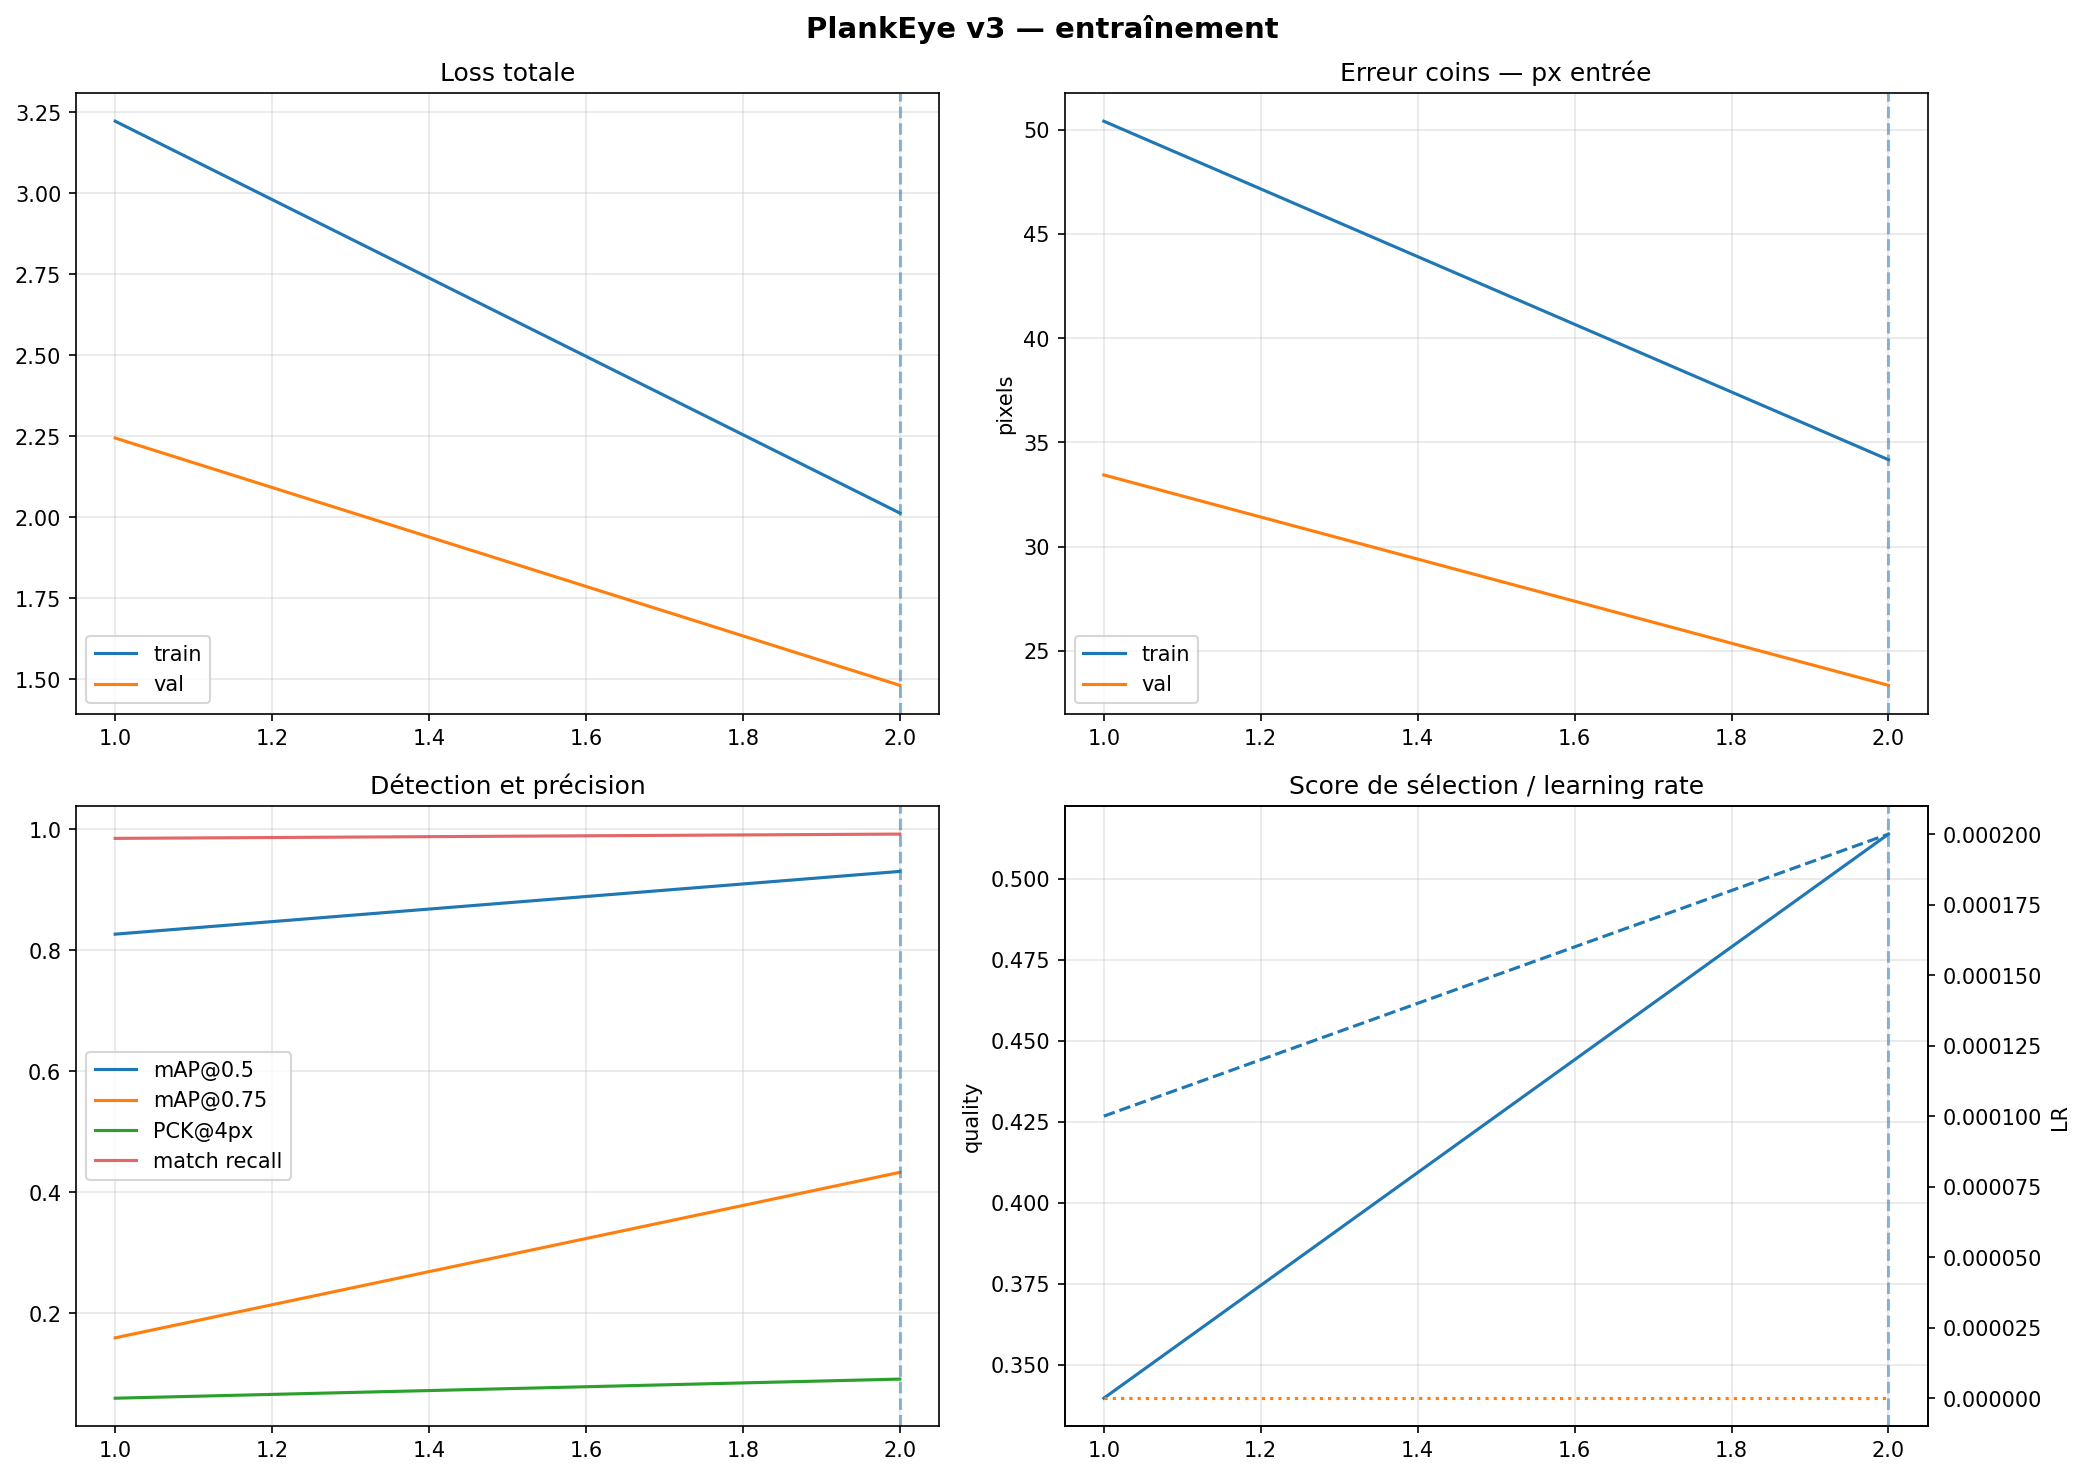

/kaggle/working/PlankEyev2_multipieces/viz_epochs_v4_1class_512_data_kaggle/epoch_002.png


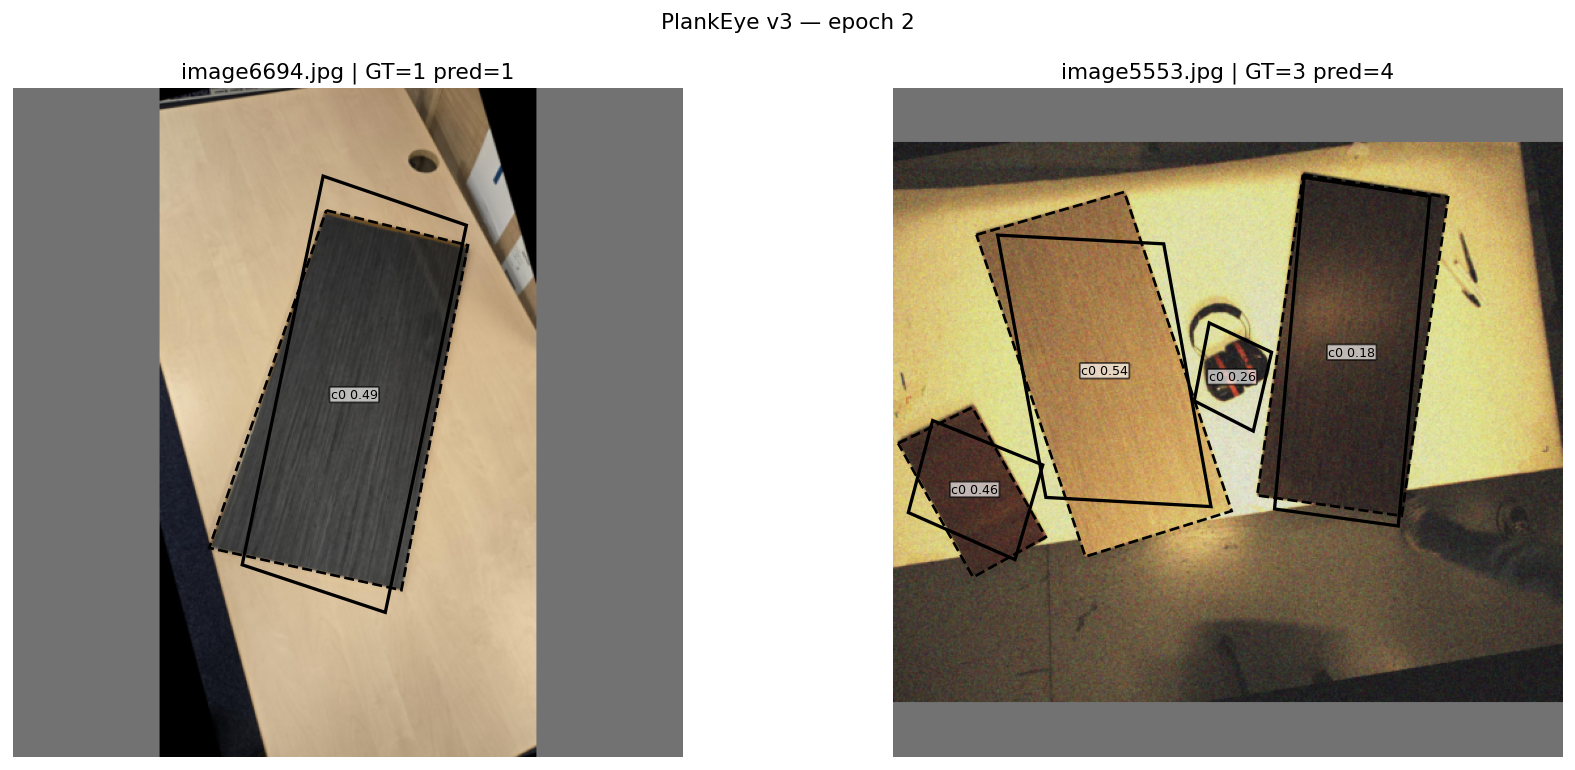

In [52]:
from pathlib import Path
from IPython.display import display
from PIL import Image

PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")

pngs = sorted(PROJECT.rglob("*.png"))

print(f"{len(pngs)} PNG trouvés\n")

for p in pngs:
    print(p)
    display(Image.open(p))

## curve d'apprentissage

In [53]:
from IPython.display import display
from PIL import Image

display(Image.open(
    "/kaggle/working/PlankEyev2_multipieces/training_curves_v4_1class_512_data_gan.png"
))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/PlankEyev2_multipieces/training_curves_v4_1class_512_data_gan.png'

## 10 — Optionnel : créer un ZIP manuel des checkpoints

Cette cellule crée aussi un ZIP dans `/kaggle/working`, pratique si tu veux le conserver dans les Outputs/Save Version ou le récupérer manuellement.

In [ ]:
from pathlib import Path
import shutil

PROJECT = Path("/kaggle/working/PlankEyev2_multipieces")
EXPORT_DIR = Path("/kaggle/working/PlankEye_data_kaggle_checkpoints_export")

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)
EXPORT_DIR.mkdir(parents=True)

for name in (
    "best_plankeye_v4_1class_512_data_kaggle.pt",
    "last_plankeye_v4_1class_512_data_kaggle.pt",
    "training_curves_v4_1class_512_data_kaggle.png",
    "split_plankeye_v4_1class_data_kaggle.json",
):
    src = PROJECT / name
    if src.exists():
        shutil.copy2(src, EXPORT_DIR / name)

zip_path = shutil.make_archive(
    "/kaggle/working/PlankEye_DATA_KAGGLE_checkpoints_export",
    "zip",
    EXPORT_DIR,
)

print("ZIP créé :", zip_path)